In [45]:
colab = True
if colab:
    !git clone https://github.com/mdrs-thiago/PUC_Redes_Neurais
    import os
    os.chdir('/content/PUC_Redes_Neurais/pos_grad/lista 1')

fatal: destination path 'PUC_Redes_Neurais' already exists and is not an empty directory.


FileNotFoundError: [Errno 2] No such file or directory: '/content/PUC_Redes_Neurais/pos_grad/lista 1'

# Redes Neurais
## 1ª Lista de Exercícios - Classificação de padrões


Estudante:

Base de dados: 

### Para cada item da lista de exercício, não esqueça de fazer uma análise pertinente dos resultados obtidos.

### Guia prático

A lista de exercícios é dividida em 4 partes. Cada questão possui as seguintes seções:

* **Rascunho**: neste espaço, você pode escrever qualquer código ou teste que queira fazer, mas que *não* produza a resposta desejada.

* **Resposta**: deve conter trechos do código que produzam artefatos importantes para a análise de resultados, além de comentários e discussões sobre o item.

Não é necessário seguir esta ordem, mas é *altamente recomendável*. O intuito da lista de exercícios **não** é medir o nível de conhecimento em programação, então não se preocupe se o código não estiver da forma mais polida possível. O principal ponto a ser avaliado é a capacidade crítica de entender os fenômenos atrelados aos resultados obtidos e a discussão de resultados para um problema específico.   

Outros pontos importantes:

1. Fique atento com os hiperparâmetros iniciais desta lista. Dependendo do problema, os valores podem mudar. Para encontrar um conjunto de parâmetros razoáveis, siga o seguinte roteiro: 

    * Rode os itens 2.1 e 3.1 com os parâmetros iniciais. Se os dois resultados foram igualmente ruins, modifique os parâmetros do item 3.1 até que o resultado seja relativamente melhor que o 2.1.

    * Após obter esses melhores parâmetros iniciais, rode novamente o item 2.1 com os mesmos hiperparâmetros para uma comparação mais justa. 

2. O resultado de um modelo de Redes Neurais geralmente depende da inicialização de seus pesos. Portanto, para cada questão, obtenha um resultado médio de pelo menos 10 rodadas. A recomendação pessoal é de que faça uso do histórico existente da perda (loss) e acurácia para visualização dos resultados, com plot da média e seu intervalo de confiança em função das épocas.

In [ ]:
import numpy as np 
import pandas as pd 
import json
import matplotlib.pyplot as plt 
import seaborn as sns 
from time import sleep
import requests

import torch 
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader 

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score, KFold, train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score

from utils import CustomDataset, transform_data, plot_confusion_matrix

from typing import Tuple, Dict, List
from tqdm import tqdm 




In [ ]:
def accuracy(y_pred: torch.Tensor, y_test: torch.Tensor) -> float:
    """
    Computes the accuracy of a PyTorch model given the outputs and labels.

    Parameters:
        outputs (torch.Tensor): The model outputs.
        labels (torch.Tensor): The true labels.

    Returns:
        float: The accuracy of the model.
    """
    
    _, predictions = torch.max(y_pred, dim=1)
    correct = torch.sum(predictions == y_test)
    accuracy = correct.float() / y_test.size(0)
    acc = torch.round(accuracy * 100)
    
    return acc

def binary_acc(y_pred: torch.Tensor, y_test: torch.Tensor) -> float:
    """
    Computes the binary accuracy of a PyTorch model given the outputs and labels.

    Parameters:
        outputs (torch.Tensor): The model outputs.
        labels (torch.Tensor): The true labels.

    Returns:
        float: The accuracy of the model.
    """
    
    predictions = torch.round(torch.sigmoid(y_pred))
    correct = torch.sum(predictions == y_test)
    accuracy = correct.float() / y_test.size(0)
    acc = torch.round(accuracy * 100)
    
    return acc

In [ ]:
def evaluate(model: torch.nn.Module, val_set: Tuple[torch.tensor, torch.tensor], 
            criterion: torch.nn.Module, binary:bool =True) -> Tuple[torch.tensor, float, float]:
    """
    Evaluates a Pytorch model on a given dataset.
    Parameters:
    model (torch.nn.Module): The model to be evaluated
    data (tuple): A tuple containing the data and labels
    criterion (torch.nn.Module): The loss function to be used
    binary (bool): Boolean indicating whether the task is binary classification or not. Default: True
    Returns:
    tuple: A tuple containing predicted labels, loss, and accuracy
    """
    
    X = val_set.X_data
    y = val_set.y_data
    
    with torch.no_grad():
        y_pred = model(X)
    loss = criterion(y_pred, y)
    if binary:
        acc = binary_acc(y_pred, y)
    else:
        acc = accuracy(y_pred, y)
    y_pred = torch.argmax(y_pred, dim=1)

    return y_pred, loss.item(), acc.item()


In [ ]:
def train(model: torch.nn.Module , train_loader: torch.utils.data.DataLoader, 
         val_set: Tuple[torch.Tensor, torch.Tensor], epochs: int, device: torch.device, 
         lr: float, binary: bool = True, skip: int = 1) -> Tuple[Dict[str, List[float]], torch.Tensor]:
    """
    Trains a Pytorch model on a given training data.

    Parameters:
    model (torch.nn.Module): The model to be trained
    train_loader (DataLoader): The training data in the form of a Pytorch DataLoader
    val_set (tuple): A tuple containing the validation data and labels
    epochs (int): The number of times the training data should be passed through the model
    device (str or torch.device): The device on which to perform the computations (e.g. 'cpu' or 'cuda')
    lr (float): The learning rate for the optimizer
    binary (bool): Boolean indicating whether the task is binary classification or not. Default: True
    skip (int): The number of epochs after which the training and validation results will be printed. Default: 1

    Returns:
    tuple: A tuple containing the training history and the predicted labels after training
    """

    if binary:
        criterion = nn.BCEWithLogitsLoss()
    else:
        criterion = nn.CrossEntropyLoss()


    optimizer = torch.optim.SGD(model.parameters(), lr=lr)

    history = {'acc_train' : [], 'loss_train': [], 'acc_val': [], 'loss_val': []}

    for e in tqdm(range(1, epochs+1)):

        y_hat = np.array([])

        train_epoch_loss = 0
        train_epoch_acc = 0
        model.train()
        for X_train_batch, y_train_batch in train_loader:
            X, y = X_train_batch.to(device), y_train_batch.to(device)
            optimizer.zero_grad()
            
            y_pred = model(X)
            
            loss = criterion(y_pred, y)
            if binary:
                acc = binary_acc(y_pred,y)
            else:
                acc = accuracy(y_pred, y)
            
            loss.backward()
            optimizer.step()
            
            train_epoch_loss += loss.item()
            train_epoch_acc += acc.item()
            y_p = torch.argmax(y_pred, dim=1)
            y_hat = np.concatenate((y_hat, y_p))


        model.eval()
        _, val_loss, val_acc = evaluate(model, val_set, criterion, binary=binary)

        history['acc_train'].append(train_epoch_acc/len(train_loader))
        history['loss_train'].append(train_epoch_loss/len(train_loader))
        history['acc_val'].append(val_acc)
        history['loss_val'].append(val_loss)

        if e%skip == 0:
            print(f'Epoch {e+0:03}: | Train Loss: {train_epoch_loss/len(train_loader):.3f} | Val Loss: {val_loss:.4f} | Train Acc: {train_epoch_acc/len(train_loader):.4f}| Val Acc: {val_acc:.4f}')
    return history, y_hat

In [ ]:
class NeuralNetwork(torch.nn.Module):
  '''
  Objeto criado para facilitar o desenvolvimento dos scripts das aulas práticas.
  Opção alternativa à criação externa fdo modelo. Basicamente serve como um 
  'agregador'  de trechos comuns para a criação do modelo. Por exemplo, ao invés
  de gastar n+1 linhas para a criação de um modelo com n camadas, podemos criar 
  o mesmo modelo com apenas uma linha.
  
  Parâmetros de entrada: 
  - hidden_neurons: Lista com a quantidade de neurônios na camada escondida. 
  - hidden_activation: Função de ativação para cada camada escondida. Aceita 
  como parâmetro string ou lista. Caso o parâmetro receba string, então a mesma
  função de ativação é utilizada para todas as camadas escondidas. Caso seja uma 
  lista, cada camada terá sua propria função de ativação definida pela lista.
  - output_activation: Função de ativação para a camada de saída.
  - lr: Taxa de aprendizado
  - n_input: Tamanho do vetor de entrada.
  - n_output: Saída do modelo.
  ''' 
  def __init__(self,hidden_neurons = 4, hidden_activation = 'relu', output_activation='softmax', lr = 0.05, n_input = 1, n_output = 1):
    super(NeuralNetwork, self).__init__()

    self.activations = {'relu': nn.ReLU(), 'sigmoid':nn.Sigmoid(), 'softmax':nn.Softmax()}

    self.fc1 = nn.Linear(n_input, hidden_neurons)
    self.ha = self.activations[hidden_activation]
    self.fc2 = nn.Linear(hidden_neurons, n_output)

  def forward(self,x):
    h = self.fc1(x)
    h1 = self.ha(h) 
    y = self.fc2(h1) 
    return y

  def predict(self, x, binary=True):
    y_hat = self.forward(x)

    if binary:
      y_pred = torch.round(torch.sigmoid(y_hat))
      y_pred = y_pred.detach().numpy()
    else:
      y_pred = torch.argmax(y_hat, dim=1)

    return y_pred

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Preparação dos dados

Não esqueça de verificar o path para a pasta. Mude também o filename, de acordo com a base de dados. Esta parte é necessária para garantir que as colunas sejam corretamente identificadas de acordo com a natureza dos dados.

In [ ]:
dataset_name = 'analise_credito'
dataset_path = f'https://raw.githubusercontent.com/mdrs-thiago/PUC_Redes_Neurais/main/datasets/c_{dataset_name}.csv'
info_path = f'https://raw.githubusercontent.com/mdrs-thiago/PUC_Redes_Neurais/main/datasets/data_info/{dataset_name}/data_info.json'
dataset = pd.read_csv(dataset_path)

In [ ]:
resp = requests.get(info_path)
info = json.loads(resp.text)

In [ ]:
for col, k in info.items():
    if k == 'categorical':
        dataset[col] = dataset[col].astype(object)

In [ ]:
for i in dataset.dtypes.items():
    print(i)

('ESTC', dtype('O'))
('NDEP', dtype('int64'))
('RENDA', dtype('int64'))
('TIPOR', dtype('O'))
('VBEM', dtype('int64'))
('NPARC', dtype('int64'))
('VPARC', dtype('int64'))
('TEL', dtype('O'))
('IDADE', dtype('int64'))
('RESMS', dtype('int64'))
('ENTRADA', dtype('int64'))
('target', dtype('int64'))


## Parte I - Compreensão do problema e análise de variáveis

Total: 0,5 pts.


1)	Neste primeiro momento, iremos verificar a qualidade dos dados. Verifique se os dados estão aptos para o treinamento de Redes Neurais (i.e., verifique a existência de dados nulos, atributos de identificação ou duplicados). Implemente o código que execute as técnicas necessárias e discuta o racional utilizado para o tratamento de dados. 

Rascunho

Resposta

O objetivo deste código é realizar uma inspeção rápida e de alto nível de um conjunto de dados (dataset) durante as fases iniciais da análise exploratória de dados (EDA).

In [ ]:
num_linhas, num_colunas = dataset.shape
print('Shape do dataset:', dataset.shape)
dataset.sample(10)

Shape do dataset: (1500, 12)


,ESTC,NDEP,RENDA,TIPOR,VBEM,NPARC,VPARC,TEL,IDADE,RESMS,ENTRADA,target
48,1,0,312,0,499,12,69,0,21,18,0,1
554,1,0,480,0,398,10,61,0,23,0,0,1
297,0,0,300,1,455,10,69,0,46,6,0,1
845,0,0,1500,1,495,2,175,0,44,6,175,0
1444,0,0,500,1,330,10,50,0,40,6,0,0
747,1,0,600,0,1090,12,96,1,34,0,390,1
949,1,0,2500,1,930,10,140,0,27,6,0,1
696,1,0,1200,0,416,6,89,0,32,6,0,1
947,1,0,301,1,490,12,66,0,41,6,0,1
445,0,3,1500,1,560,12,76,0,48,6,0,0


In [ ]:
# Basic quality checks
print(f"Dataset shape: {dataset.shape[1]} variáveis (colunas), e {dataset.shape[0]} amostras (linhas)")
print("\nMissing values by column:")
print(dataset.isnull().sum())

# Verificação de dados duplicados
duplicates_original = dataset.duplicated().sum()
print("\nLinhas duplicadas:", dataset.duplicated().sum())

Dataset shape: 12 variáveis (colunas), e 1500 amostras (linhas)

Missing values by column:
ESTC       0
NDEP       0
RENDA      0
TIPOR      0
VBEM       0
NPARC      0
VPARC      0
TEL        0
IDADE      0
RESMS      0
ENTRADA    0
target     0
dtype: int64

Linhas duplicadas: 5


In [ ]:
dataset = dataset.drop_duplicates().reset_index(drop=True)
print(f'Linhas após remoção de duplicatas: {len(dataset)}')
print(f'Número de duplicatas removidas: {duplicates_original - dataset.duplicated().sum()}')

Linhas após remoção de duplicatas: 1495
Número de duplicatas removidas: 5


Modelos baseados em gradiente descendente, como as Redes Neurais Artificiais (RNAs), realizam operações matemáticas diretas com os tensores de entrada. A presença de valores `NaN` (nulos) quebra o cálculo do gradiente, impedindo o treinamento. Dados duplicados, por sua vez, causam um viés (bias) no modelo, fazendo com que ele dê importância desproporcional a certas amostras, o que prejudica a capacidade de generalização (o modelo "decora" a amostra duplicada em vez de aprender o padrão geral).

2) Utilize técnicas de seleção de variáveis e visualização de gráficos para compreender melhor a relação entre as variáveis do problema. Avalie e discuta os resultados obtidos. 

Rascunho

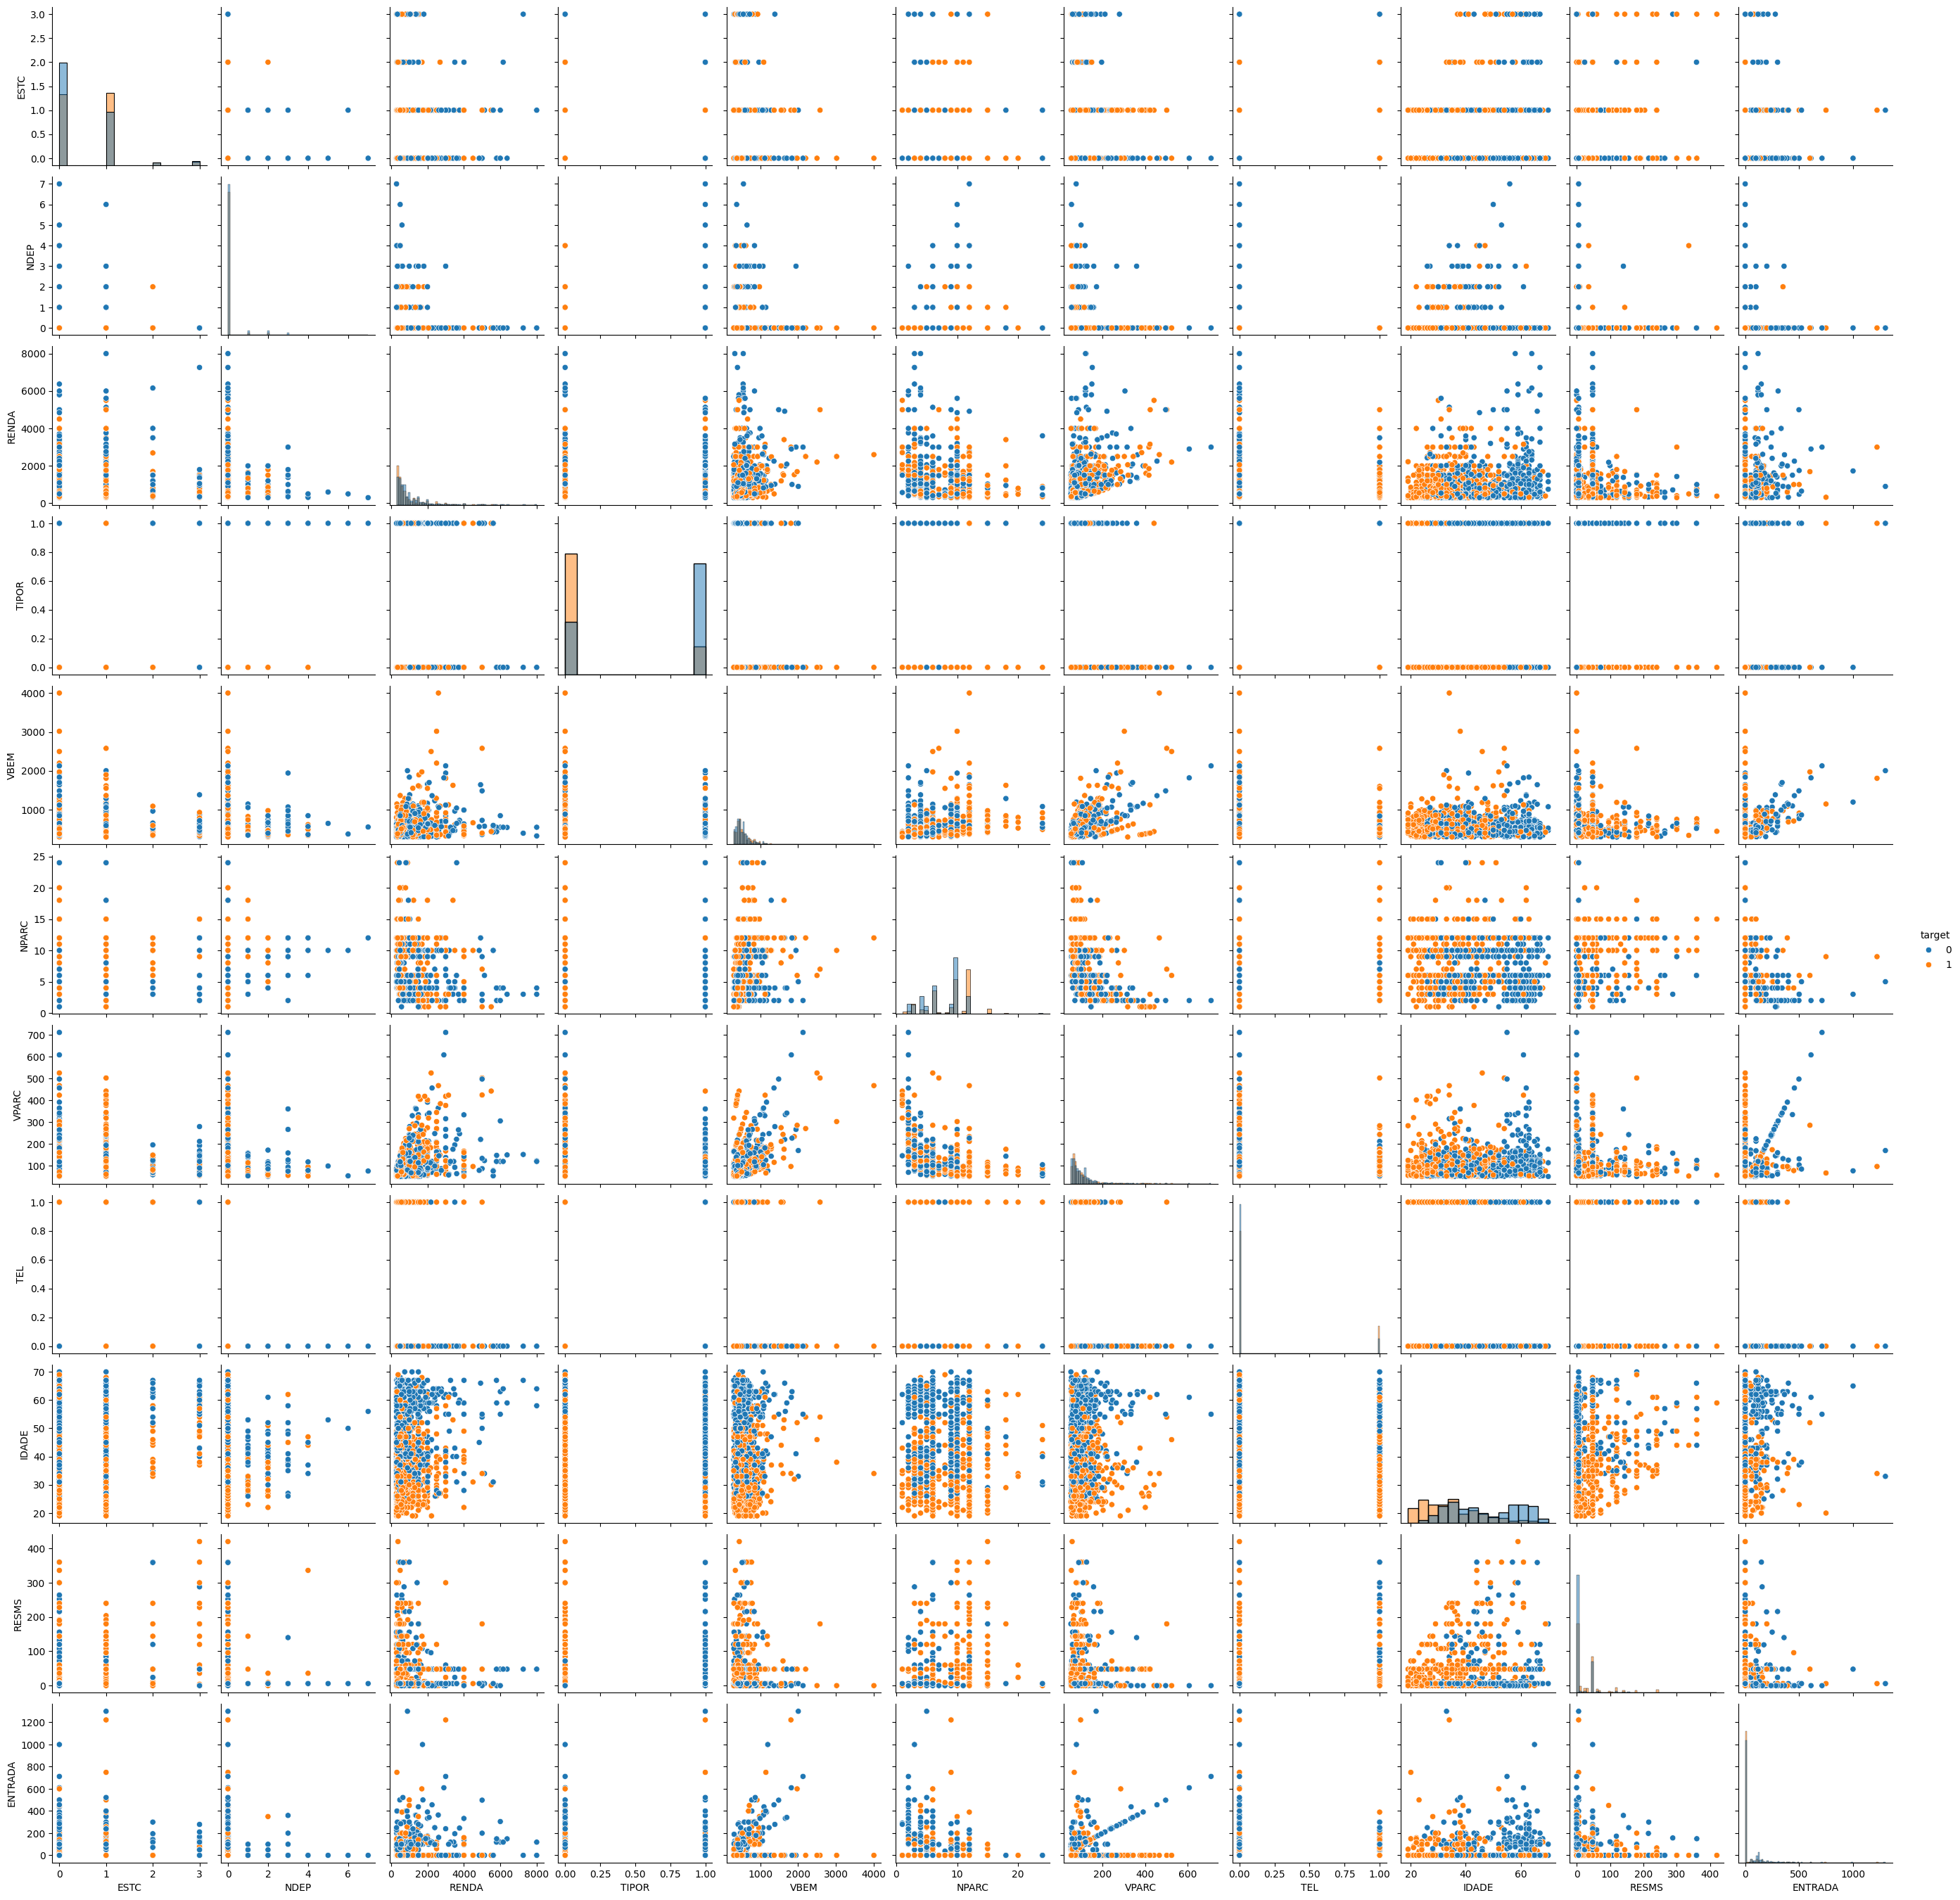

In [ ]:
sns.pairplot(dataset, hue="target", diag_kind="hist")

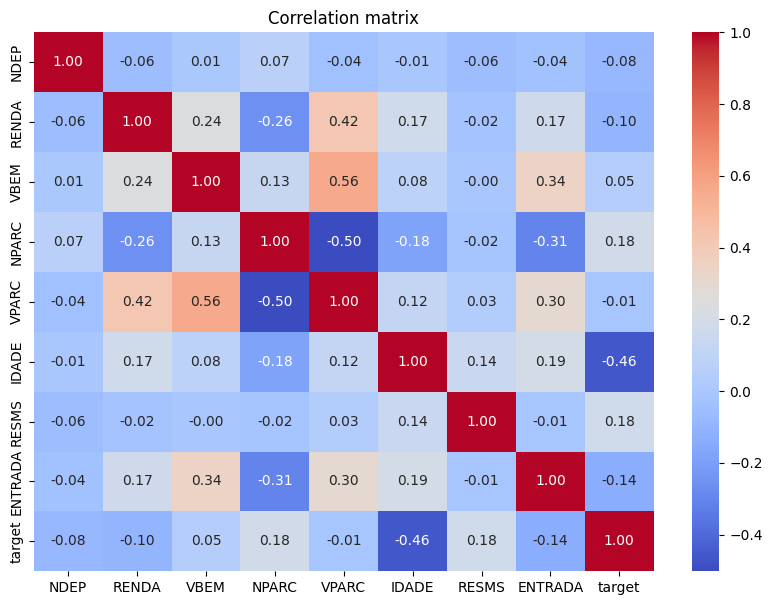

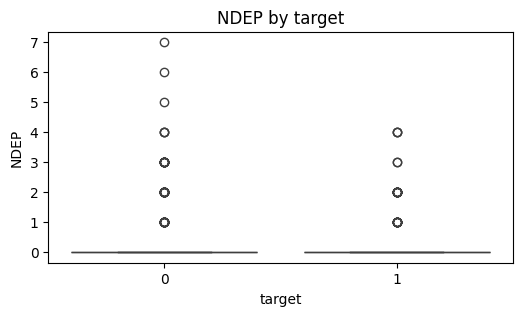

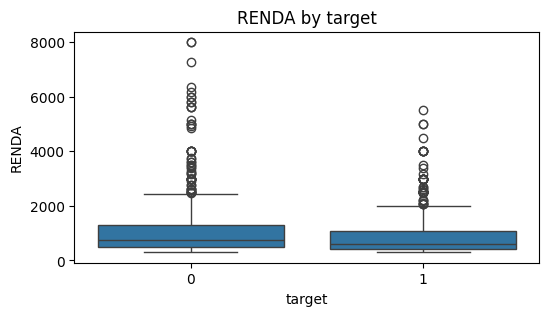

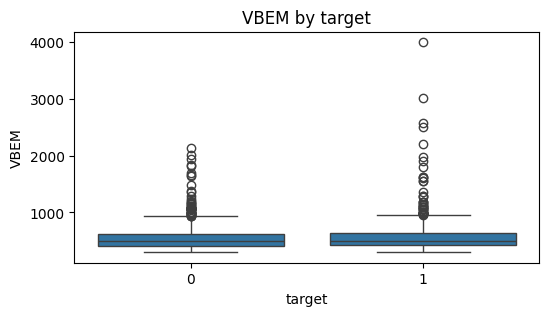

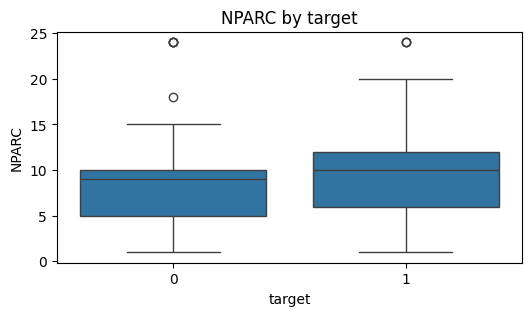

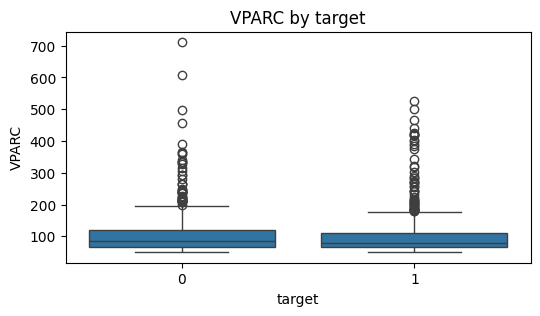

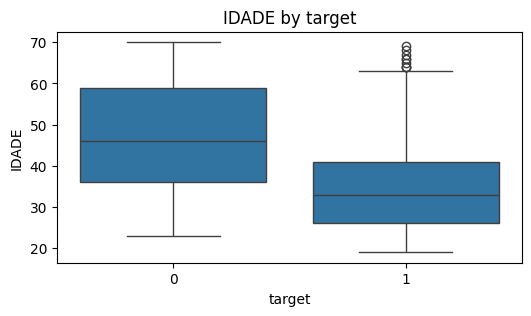

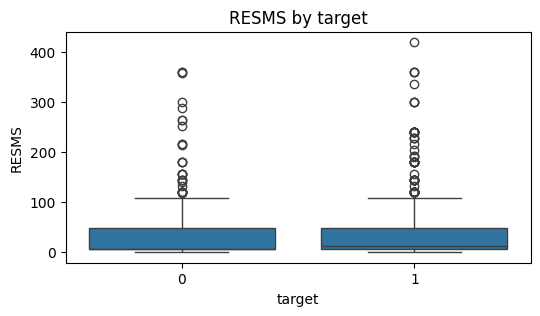

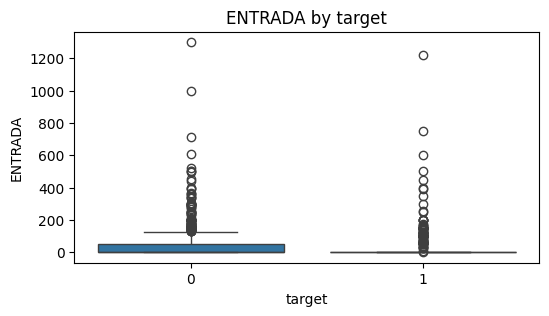

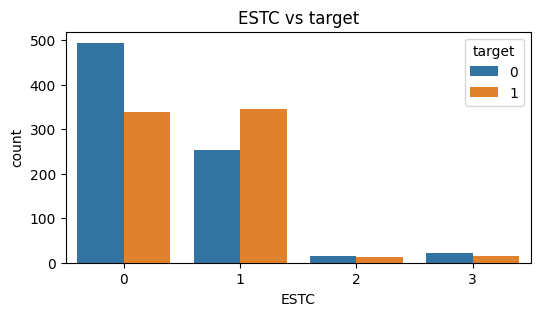

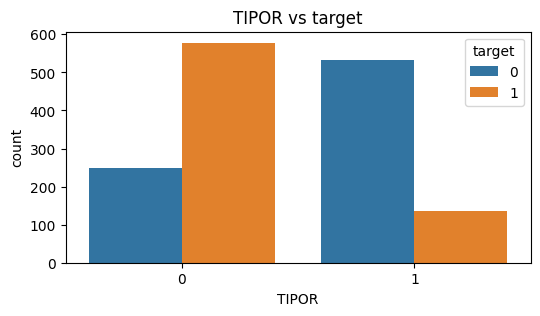

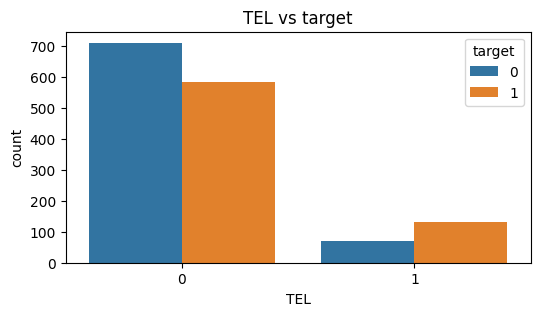

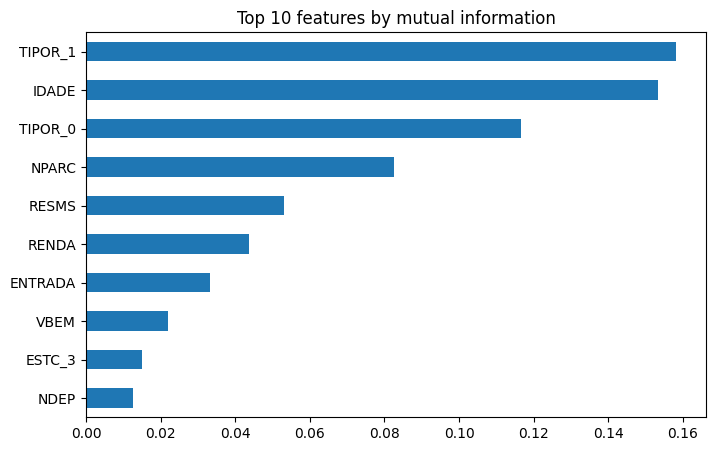

TIPOR_1    0.158267
IDADE      0.153342
TIPOR_0    0.116647
NPARC      0.082459
RESMS      0.053169
RENDA      0.043828
ENTRADA    0.033134
VBEM       0.021870
ESTC_3     0.015097
NDEP       0.012680
dtype: float64

In [ ]:
# Correlation among numerical variables
plt.figure(figsize=(10, 7))
sns.heatmap(dataset.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation matrix")
plt.show()

# Compare distributions by target
num_cols = ["NDEP", "RENDA", "VBEM", "NPARC", "VPARC", "IDADE", "RESMS", "ENTRADA"]
for col in num_cols:
    plt.figure(figsize=(6, 3))
    sns.boxplot(data=dataset, x="target", y=col)
    plt.title(f"{col} by target")
    plt.show()

# Categorical variables vs target
cat_cols = ["ESTC", "TIPOR", "TEL"]
for col in cat_cols:
    plt.figure(figsize=(6, 3))
    sns.countplot(data=dataset, x=col, hue="target")
    plt.title(f"{col} vs target")
    plt.show()

# A simple univariate ranking
from sklearn.feature_selection import mutual_info_classif

temp_df = transform_data(dataset, normalize=True)
X_fs = temp_df.drop(columns=["target"]).values
y_fs = temp_df["target"].values

mi = mutual_info_classif(X_fs, y_fs, random_state=42)
mi_series = pd.Series(mi, index=temp_df.drop(columns=["target"]).columns).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
mi_series.head(10).sort_values().plot(kind="barh")
plt.title("Top 10 features by mutual information")
plt.show()

display(mi_series.head(10))

Resposta

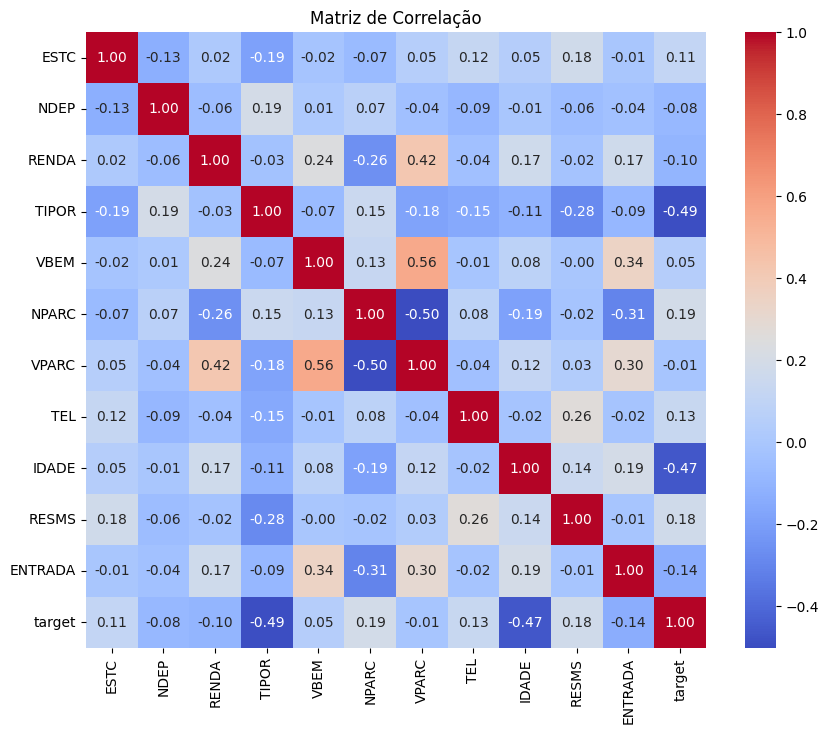

In [ ]:
# Matriz de correlação para entender a relação linear entre as variáveis
plt.figure(figsize=(10, 8))
corr = dataset.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matriz de Correlação")
plt.show()

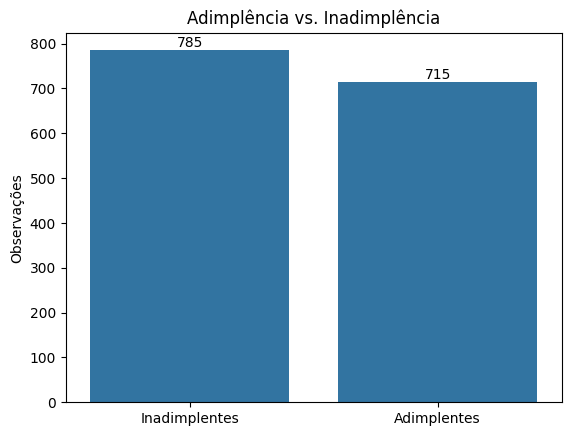

In [64]:
# Distribuição da variável alvo (Target)
fig1 = sns.countplot(x='target', data=dataset)
plt.title("Adimplência vs. Inadimplência")
plt.ylabel("Observações")
plt.xlabel("") # Limpa o título do eixo x para um visual mais limpo

# 1. Altera os valores numéricos 0 e 1 para rótulos textuais
fig1.set_xticks([0, 1])
fig1.set_xticklabels(['Inadimplentes', 'Adimplentes'])

# Adiciona os rótulos numéricos no topo de cada barra
fig1.bar_label(fig1.containers[0])

plt.show()

In [63]:
defaulter = dataset["target"].value_counts(normalize=True)[0]
current   = dataset["target"].value_counts(normalize=True)[1]

print("\nDistribuição de Frequência:")
print(dataset["target"].value_counts(normalize=True).rename("CLASSE").name)
print(f"Inadimplentes: {defaulter.round(4) * 100}%")
print(f"Adimplentes: {current.round(4) * 100}%")


Distribuição de Frequência:
CLASSE
Inadimplentes: 52.33%
Adimplentes: 47.67%


In [52]:
print("\nEstatísticas descritivas:")
display(dataset.describe())

# Optional: inspect impossible or suspicious values
for col in ["NDEP", "RENDA", "VBEM", "NPARC", "VPARC", "IDADE", "RESMS", "ENTRADA"]:
    print(f"{col}: min={dataset[col].min()}, max={dataset[col].max()}")


Estatísticas descritivas:


,NDEP,RENDA,VBEM,NPARC,VPARC,IDADE,RESMS,ENTRADA,target
count,1500.000000,1500.00000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000
mean,0.126667,984.51200,562.031333,8.392667,102.247333,41.210667,31.528667,32.255333,0.476667
std,0.572865,905.53292,265.690646,3.609131,62.987325,13.202266,52.662099,94.307614,0.499622
min,0.000000,300.00000,300.000000,1.000000,50.000000,19.000000,0.000000,0.000000,0.000000
25%,0.000000,467.50000,410.000000,6.000000,66.000000,31.000000,6.000000,0.000000,0.000000
50%,0.000000,650.00000,490.000000,10.000000,83.000000,39.000000,6.000000,0.000000,0.000000
75%,0.000000,1200.00000,618.000000,10.000000,118.000000,52.000000,48.000000,0.000000,1.000000
max,7.000000,8000.00000,4000.000000,24.000000,711.000000,70.000000,420.000000,1300.000000,1.000000


NDEP: min=0, max=7
RENDA: min=300, max=8000
VBEM: min=300, max=4000
NPARC: min=1, max=24
VPARC: min=50, max=711
IDADE: min=19, max=70
RESMS: min=0, max=420
ENTRADA: min=0, max=1300


## Parte II. Treinamento do modelo de Rede Neural - Baseline e Efeito da Normalização 

Total: 1,5 pts.

1)	Neste momento, iremos fazer a primeira avaliação de resultados do modelo MLP. Com base no que foi aprendido em sala de aula, escolha um valor inicial para os hiperparâmetros `lr` (taxa de aprendizado), `epochs` (número de épocas), `hidden_neurons` (número de neurônios na camada escondida) e `batch_size` (tamanho do lote), justificando sua escolha. Faça o treinamento e responda observando o resultado do treinamento: o modelo foi capaz de aprender? O que pode ser possível inferir sobre a capacidade de generalização?

#### Rascunho

#### Resposta

#### Hiperparâmetros iniciais

In [21]:
# ======================== Hiperparâmetros base ========================
# Justificativa:
#  lr=0.01            → taxa pequena garante convergência estável com SGD
#  epochs=250         → suficiente para observar plateau (como visto no notebook original)
#  hidden_neurons=16  → regra prática: 1-2x o número de features 
#  batch_size=32      → mini-batch equilibra velocidade e estabilidade do gradiente
lr             = 0.01
epochs         = 250
hidden_neurons = 16
batch_size     = 32

In [22]:
# ====== Prepara os dados SEM NORMALIZAÇÃO ======
new_df = transform_data(dataset, normalize=False)
new_df.sample(10)

,ESTC_0,ESTC_1,ESTC_2,ESTC_3,NDEP,RENDA,TIPOR_0,TIPOR_1,VBEM,NPARC,VPARC,TEL_0,TEL_1,IDADE,RESMS,ENTRADA,target
876,0,0,0,1,0,335,1,0,396,10,60,0,1,62,0,0,0
58,0,1,0,0,0,1500,0,1,984,9,140,1,0,34,6,117,1
314,0,1,0,0,0,500,1,0,633,6,106,1,0,36,48,0,1
653,1,0,0,0,1,400,0,1,420,10,58,1,0,49,6,0,0
1457,0,1,0,0,0,479,0,1,329,4,97,1,0,65,6,0,0
422,0,1,0,0,0,566,1,0,556,12,76,1,0,41,120,0,1
1060,0,1,0,0,0,400,0,1,429,10,60,1,0,24,6,0,1
552,1,0,0,0,0,680,1,0,881,12,121,1,0,26,0,0,1
78,0,1,0,0,0,500,1,0,401,4,118,1,0,20,12,0,1
1274,1,0,0,0,0,300,0,1,332,10,51,1,0,54,6,0,0


In [23]:
X = new_df.values[:,:-1].astype('float')
target = new_df.values[:,-1]

encoder = LabelEncoder()
y = encoder.fit_transform(target)

n_input = X.shape[1]

if np.unique(y).shape[0] <= 2:
  print('Binary classification')
  n_output = 1
  binary = True
else:
  print('Multiclass classification')
  n_output = len(encoder.classes_)
  binary = False


Binary classification


In [23]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train,y_train,test_size=0.2,random_state=42)

In [24]:
if binary:
    train_dataset = CustomDataset(torch.from_numpy(X_train).float(), torch.from_numpy(y_train).float().unsqueeze(1))
    val_dataset = CustomDataset(torch.from_numpy(X_val).float(), torch.from_numpy(y_val).float().unsqueeze(1))
    test_dataset = CustomDataset(torch.from_numpy(X_test).float(), torch.from_numpy(y_test).float().unsqueeze(1))
else:
    train_dataset = CustomDataset(torch.from_numpy(X_train).float(), torch.from_numpy(y_train).long())
    val_dataset = CustomDataset(torch.from_numpy(X_val).float(), torch.from_numpy(y_val).long())
    test_dataset = CustomDataset(torch.from_numpy(X_test).float(), torch.from_numpy(y_test).long())

train_loader = DataLoader(dataset=train_dataset,batch_size=batch_size)
val_loader = DataLoader(dataset=val_dataset, batch_size=1)
test_loader = DataLoader(dataset=test_dataset, batch_size=1)

In [25]:
model = NeuralNetwork(n_input = n_input, hidden_neurons=hidden_neurons,
                      n_output=n_output,output_activation='sigmoid')

In [26]:
history, y_hat = train(model, train_loader, val_dataset, 
                       epochs=epochs, lr=lr, device=device, 
                       binary=binary)

  2%|▏         | 6/250 [00:00<00:28,  8.52it/s]

Epoch 001: | Train Loss: 36.421 | Val Loss: 0.6928 | Train Acc: 51.3333| Val Acc: 52.0000
Epoch 002: | Train Loss: 0.694 | Val Loss: 0.6927 | Train Acc: 51.7333| Val Acc: 52.0000
Epoch 003: | Train Loss: 0.693 | Val Loss: 0.6926 | Train Acc: 51.8333| Val Acc: 52.0000
Epoch 004: | Train Loss: 0.693 | Val Loss: 0.6926 | Train Acc: 51.8333| Val Acc: 52.0000
Epoch 005: | Train Loss: 0.693 | Val Loss: 0.6925 | Train Acc: 51.8333| Val Acc: 52.0000
Epoch 006: | Train Loss: 0.693 | Val Loss: 0.6925 | Train Acc: 51.8333| Val Acc: 52.0000
Epoch 007: | Train Loss: 0.693 | Val Loss: 0.6924 | Train Acc: 51.8333| Val Acc: 52.0000
Epoch 008: | Train Loss: 0.692 | Val Loss: 0.6924 | Train Acc: 51.8333| Val Acc: 52.0000
Epoch 009: | Train Loss: 0.692 | Val Loss: 0.6924 | Train Acc: 51.8333| Val Acc: 52.0000


  6%|▋         | 16/250 [00:01<00:11, 20.85it/s]

Epoch 010: | Train Loss: 0.692 | Val Loss: 0.6924 | Train Acc: 51.8333| Val Acc: 52.0000
Epoch 011: | Train Loss: 0.692 | Val Loss: 0.6924 | Train Acc: 51.8333| Val Acc: 52.0000
Epoch 012: | Train Loss: 0.692 | Val Loss: 0.6923 | Train Acc: 51.8333| Val Acc: 52.0000
Epoch 013: | Train Loss: 0.692 | Val Loss: 0.6923 | Train Acc: 51.9333| Val Acc: 52.0000
Epoch 014: | Train Loss: 0.692 | Val Loss: 0.6923 | Train Acc: 51.9333| Val Acc: 52.0000
Epoch 015: | Train Loss: 0.692 | Val Loss: 0.6923 | Train Acc: 51.9333| Val Acc: 52.0000
Epoch 016: | Train Loss: 0.692 | Val Loss: 0.6923 | Train Acc: 51.9333| Val Acc: 52.0000
Epoch 017: | Train Loss: 0.692 | Val Loss: 0.6923 | Train Acc: 51.9333| Val Acc: 52.0000


  8%|▊         | 20/250 [00:01<00:09, 24.50it/s]

...

Epoch 231: | Train Loss: 0.692 | Val Loss: 0.6923 | Train Acc: 51.9333| Val Acc: 52.0000
Epoch 232: | Train Loss: 0.692 | Val Loss: 0.6923 | Train Acc: 51.9333| Val Acc: 52.0000
Epoch 233: | Train Loss: 0.692 | Val Loss: 0.6923 | Train Acc: 51.9333| Val Acc: 52.0000
Epoch 234: | Train Loss: 0.692 | Val Loss: 0.6923 | Train Acc: 51.9333| Val Acc: 52.0000
Epoch 235: | Train Loss: 0.692 | Val Loss: 0.6923 | Train Acc: 51.9333| Val Acc: 52.0000
Epoch 236: | Train Loss: 0.692 | Val Loss: 0.6923 | Train Acc: 51.9333| Val Acc: 52.0000
Epoch 237: | Train Loss: 0.692 | Val Loss: 0.6923 | Train Acc: 51.9333| Val Acc: 52.0000
Epoch 238: | Train Loss: 0.692 | Val Loss: 0.6923 | Train Acc: 51.9333| Val Acc: 52.0000
Epoch 239: | Train Loss: 0.692 | Val Loss: 0.6923 | Train Acc: 51.9333| Val Acc: 52.0000
Epoch 240: | Train Loss: 0.692 | Val Loss: 0.6923 | Train Acc: 51.9333| Val Acc: 52.0000


 99%|█████████▉| 247/250 [00:06<00:00, 42.36it/s]

Epoch 241: | Train Loss: 0.692 | Val Loss: 0.6923 | Train Acc: 51.9333| Val Acc: 52.0000
Epoch 242: | Train Loss: 0.692 | Val Loss: 0.6923 | Train Acc: 51.9333| Val Acc: 52.0000
Epoch 243: | Train Loss: 0.692 | Val Loss: 0.6923 | Train Acc: 51.9333| Val Acc: 52.0000
Epoch 244: | Train Loss: 0.692 | Val Loss: 0.6923 | Train Acc: 51.9333| Val Acc: 52.0000
Epoch 245: | Train Loss: 0.692 | Val Loss: 0.6923 | Train Acc: 51.9333| Val Acc: 52.0000
Epoch 246: | Train Loss: 0.692 | Val Loss: 0.6923 | Train Acc: 51.9333| Val Acc: 52.0000
Epoch 247: | Train Loss: 0.692 | Val Loss: 0.6923 | Train Acc: 51.9333| Val Acc: 52.0000
Epoch 248: | Train Loss: 0.692 | Val Loss: 0.6923 | Train Acc: 51.9333| Val Acc: 52.0000
Epoch 249: | Train Loss: 0.692 | Val Loss: 0.6923 | Train Acc: 51.9333| Val Acc: 52.0000


100%|██████████| 250/250 [00:06<00:00, 36.35it/s]

Epoch 250: | Train Loss: 0.692 | Val Loss: 0.6923 | Train Acc: 51.9333| Val Acc: 52.0000


In [26]:
def plot_history(history, title='Curvas de aprendizado'):
    """Plota loss e acurácia de treino/validação."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    epochs_range = range(1, len(history['loss_train']) + 1)

    axes[0].plot(epochs_range, history['loss_train'], label='Train Loss')
    axes[0].plot(epochs_range, history['loss_val'],   label='Val Loss')
    axes[0].set_xlabel('Época'); axes[0].set_ylabel('Loss')
    axes[0].set_title('Loss'); axes[0].legend()

    axes[1].plot(epochs_range, history['acc_train'], label='Train Acc')
    axes[1].plot(epochs_range, history['acc_val'],   label='Val Acc')
    axes[1].set_xlabel('Época'); axes[1].set_ylabel('Acurácia (%)')
    axes[1].set_title('Acurácia'); axes[1].legend()

    fig.suptitle(title); plt.tight_layout(); plt.show()

plot_history(history, 'Baseline — Sem Normalização')

NameError: name 'history' is not defined

2) Avalie agora a generalização no conjunto de teste. O que é possível afirmar sobre o resultado? Faça uma análise com base nas métricas de avaliação disponíveis para classificação (acurácia, recall, precision, F1-score)

Rascunho

#### Resposta

In [29]:
y_pred = model.predict(test_dataset.X_data, binary=binary)

              precision    recall  f1-score   support

           0       0.54      0.99      0.69       161
           1       0.00      0.00      0.00       138

    accuracy                           0.53       299
   macro avg       0.27      0.49      0.35       299
weighted avg       0.29      0.53      0.37       299



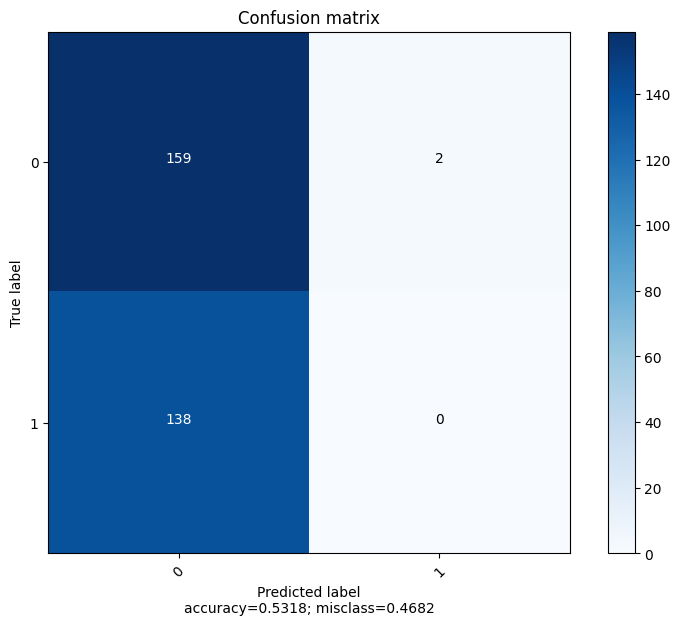

In [30]:
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

plot_confusion_matrix(cm)

3)	Agora normalize os dados de entrada e treine novamente o modelo MLP. Avalie os resultados obtidos e comente o efeito da normalização no treinamento da Rede Neural.

Rascunho

In [31]:
new_df = transform_data(dataset, normalize=True)
display(new_df.sample(10))

,ESTC_0,ESTC_1,ESTC_2,ESTC_3,NDEP,RENDA,TIPOR_0,TIPOR_1,VBEM,NPARC,VPARC,TEL_0,TEL_1,IDADE,RESMS,ENTRADA,target
134,0,1,0,0,0.000000,0.000000,0,1,0.013243,0.391304,0.001513,1,0,0.411765,0.014286,0.0,0
464,0,1,0,0,0.000000,0.064935,1,0,0.009730,0.086957,0.113464,1,0,0.117647,0.114286,0.0,1
1413,0,1,0,0,0.000000,0.038961,1,0,0.072703,0.478261,0.030257,1,0,0.470588,0.114286,0.0,1
980,1,0,0,0,0.000000,0.019481,0,1,0.083784,0.347826,0.074130,1,0,0.627451,0.014286,0.0,0
122,1,0,0,0,0.285714,0.012987,0,1,0.034865,0.391304,0.015129,1,0,0.431373,0.014286,0.0,0
860,0,1,0,0,0.000000,0.038961,0,1,0.000270,0.217391,0.022693,1,0,0.215686,0.014286,0.0,0
1212,1,0,0,0,0.000000,0.038961,0,1,0.053784,0.130435,0.145234,1,0,0.235294,0.014286,0.0,0
38,0,1,0,0,0.000000,0.012987,1,0,0.026757,0.217391,0.059002,1,0,0.000000,0.057143,0.0,1
597,1,0,0,0,0.000000,0.025974,0,1,0.026757,0.391304,0.007564,1,0,0.274510,0.014286,0.0,0
513,1,0,0,0,0.000000,0.071558,0,1,0.085946,0.391304,0.059002,1,0,0.803922,0.014286,0.0,0


In [32]:
X = new_df.values[:,:-1].astype('float')
target = new_df.values[:,-1]

encoder = LabelEncoder()
y = encoder.fit_transform(target)

n_input = X.shape[1]

if np.unique(y).shape[0] <= 2:
  print('Binary classification')
  n_output = 1

else:
  print('Multiclass classification')
  #y = to_categorical(y)
  n_output = encoder.classes_.shape[0]


X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train,y_train,test_size=0.2,random_state=42)

Binary classification


In [33]:
if binary:
    train_dataset = CustomDataset(torch.from_numpy(X_train).float(), torch.from_numpy(y_train).float().unsqueeze(1))
    val_dataset = CustomDataset(torch.from_numpy(X_val).float(), torch.from_numpy(y_val).float().unsqueeze(1))
    test_dataset = CustomDataset(torch.from_numpy(X_test).float(), torch.from_numpy(y_test).float().unsqueeze(1))
else:
    train_dataset = CustomDataset(torch.from_numpy(X_train).float(), torch.from_numpy(y_train).long())
    val_dataset = CustomDataset(torch.from_numpy(X_val).float(), torch.from_numpy(y_val).long())
    test_dataset = CustomDataset(torch.from_numpy(X_test).float(), torch.from_numpy(y_test).long())

train_loader = DataLoader(dataset=train_dataset,batch_size=batch_size)
val_loader = DataLoader(dataset=val_dataset, batch_size=1)
test_loader = DataLoader(dataset=test_dataset, batch_size=1)

In [34]:
model = NeuralNetwork(n_input = n_input, n_output=n_output,output_activation='sigmoid')
history, y_hat = train(model, train_loader, val_dataset, epochs=epochs, lr=lr, device=device, binary=binary)

  5%|▍         | 12/250 [00:00<00:04, 55.30it/s]

Epoch 001: | Train Loss: 0.722 | Val Loss: 0.7176 | Train Acc: 51.8333| Val Acc: 52.0000
Epoch 002: | Train Loss: 0.716 | Val Loss: 0.7131 | Train Acc: 51.8333| Val Acc: 52.0000
Epoch 003: | Train Loss: 0.712 | Val Loss: 0.7094 | Train Acc: 51.8333| Val Acc: 52.0000
Epoch 004: | Train Loss: 0.708 | Val Loss: 0.7062 | Train Acc: 51.8333| Val Acc: 52.0000
Epoch 005: | Train Loss: 0.705 | Val Loss: 0.7036 | Train Acc: 51.8333| Val Acc: 52.0000
Epoch 006: | Train Loss: 0.703 | Val Loss: 0.7013 | Train Acc: 51.8333| Val Acc: 52.0000
Epoch 007: | Train Loss: 0.701 | Val Loss: 0.6993 | Train Acc: 51.8333| Val Acc: 52.0000
Epoch 008: | Train Loss: 0.699 | Val Loss: 0.6975 | Train Acc: 51.8333| Val Acc: 52.0000
Epoch 009: | Train Loss: 0.697 | Val Loss: 0.6959 | Train Acc: 51.8333| Val Acc: 52.0000
Epoch 010: | Train Loss: 0.695 | Val Loss: 0.6942 | Train Acc: 51.8333| Val Acc: 52.0000
Epoch 011: | Train Loss: 0.693 | Val Loss: 0.6922 | Train Acc: 51.8333| Val Acc: 52.0000
Epoch 012: | Train Lo

  7%|▋         | 18/250 [00:00<00:04, 55.57it/s]

Epoch 013: | Train Loss: 0.689 | Val Loss: 0.6886 | Train Acc: 51.8333| Val Acc: 52.0000
Epoch 014: | Train Loss: 0.688 | Val Loss: 0.6871 | Train Acc: 51.9333| Val Acc: 52.0000
Epoch 015: | Train Loss: 0.686 | Val Loss: 0.6856 | Train Acc: 51.9333| Val Acc: 52.0000
Epoch 016: | Train Loss: 0.685 | Val Loss: 0.6840 | Train Acc: 51.9333| Val Acc: 52.0000
Epoch 017: | Train Loss: 0.683 | Val Loss: 0.6821 | Train Acc: 52.1333| Val Acc: 52.0000
Epoch 018: | Train Loss: 0.680 | Val Loss: 0.6800 | Train Acc: 52.7000| Val Acc: 53.0000
Epoch 019: | Train Loss: 0.678 | Val Loss: 0.6776 | Train Acc: 54.5333| Val Acc: 56.0000
Epoch 020: | Train Loss: 0.675 | Val Loss: 0.6746 | Train Acc: 56.5000| Val Acc: 60.0000
Epoch 021: | Train Loss: 0.672 | Val Loss: 0.6714 | Train Acc: 62.4000| Val Acc: 68.0000


 12%|█▏        | 30/250 [00:00<00:04, 44.99it/s]

...

Epoch 231: | Train Loss: 0.328 | Val Loss: 0.2927 | Train Acc: 88.3667| Val Acc: 92.0000
Epoch 232: | Train Loss: 0.328 | Val Loss: 0.2925 | Train Acc: 88.3667| Val Acc: 92.0000
Epoch 233: | Train Loss: 0.328 | Val Loss: 0.2923 | Train Acc: 88.3667| Val Acc: 92.0000
Epoch 234: | Train Loss: 0.328 | Val Loss: 0.2922 | Train Acc: 88.3667| Val Acc: 92.0000
Epoch 235: | Train Loss: 0.328 | Val Loss: 0.2920 | Train Acc: 88.4667| Val Acc: 92.0000
Epoch 236: | Train Loss: 0.327 | Val Loss: 0.2919 | Train Acc: 88.5667| Val Acc: 92.0000
Epoch 237: | Train Loss: 0.327 | Val Loss: 0.2917 | Train Acc: 88.5667| Val Acc: 92.0000


 98%|█████████▊| 244/250 [00:05<00:00, 32.65it/s]

Epoch 238: | Train Loss: 0.327 | Val Loss: 0.2916 | Train Acc: 88.5667| Val Acc: 92.0000
Epoch 239: | Train Loss: 0.327 | Val Loss: 0.2914 | Train Acc: 88.4667| Val Acc: 92.0000
Epoch 240: | Train Loss: 0.327 | Val Loss: 0.2912 | Train Acc: 88.3667| Val Acc: 92.0000
Epoch 241: | Train Loss: 0.327 | Val Loss: 0.2911 | Train Acc: 88.3667| Val Acc: 92.0000
Epoch 242: | Train Loss: 0.327 | Val Loss: 0.2909 | Train Acc: 88.3667| Val Acc: 92.0000
Epoch 243: | Train Loss: 0.326 | Val Loss: 0.2908 | Train Acc: 88.3667| Val Acc: 92.0000
Epoch 244: | Train Loss: 0.326 | Val Loss: 0.2906 | Train Acc: 88.3667| Val Acc: 92.0000
Epoch 245: | Train Loss: 0.326 | Val Loss: 0.2905 | Train Acc: 88.3667| Val Acc: 92.0000
Epoch 246: | Train Loss: 0.326 | Val Loss: 0.2903 | Train Acc: 88.3667| Val Acc: 92.0000
Epoch 247: | Train Loss: 0.326 | Val Loss: 0.2901 | Train Acc: 88.3667| Val Acc: 92.0000
Epoch 248: | Train Loss: 0.326 | Val Loss: 0.2900 | Train Acc: 88.3667| Val Acc: 92.0000


100%|██████████| 250/250 [00:06<00:00, 40.95it/s]

Epoch 249: | Train Loss: 0.326 | Val Loss: 0.2898 | Train Acc: 88.3667| Val Acc: 92.0000
Epoch 250: | Train Loss: 0.326 | Val Loss: 0.2897 | Train Acc: 88.3667| Val Acc: 92.0000


Resposta

In [35]:
y_pred = model.predict(test_dataset.X_data,binary=binary)


=== Relatório de classificação — COM normalização ===
              precision    recall  f1-score   support

           0       0.89      0.97      0.93       161
           1       0.96      0.86      0.91       138

    accuracy                           0.92       299
   macro avg       0.93      0.92      0.92       299
weighted avg       0.92      0.92      0.92       299



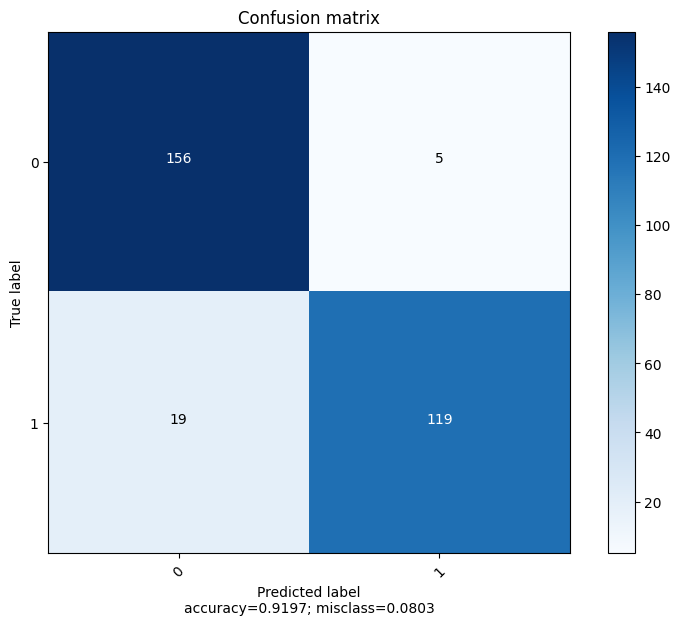

In [36]:
print('=== Relatório de classificação — COM normalização ===')
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

plot_confusion_matrix(cm)

## Parte 3 - Avaliando hiperparâmetros do modelo

1)	Modifique o tempo de treinamento (épocas) da Rede Neural. Escolha valores distintos (e.g. 1 e 1000 épocas) e avalie os resultados.

#### Rascunho

#### Resposta

In [37]:
def build_datasets(df, batch_size=32, test_size=0.2, val_size=0.2, random_state=42):
    X = df.values[:, :-1].astype("float")
    target = df.values[:, -1]

    encoder = LabelEncoder()
    y = encoder.fit_transform(target)

    n_input = X.shape[1]
    binary = len(np.unique(y)) <= 2
    n_output = 1 if binary else len(encoder.classes_)

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=random_state)
    X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=val_size, random_state=random_state)

    if binary:
        train_dataset = CustomDataset(torch.from_numpy(X_train).float(), torch.from_numpy(y_train).float().unsqueeze(1))
        val_dataset = CustomDataset(torch.from_numpy(X_val).float(), torch.from_numpy(y_val).float().unsqueeze(1))
        test_dataset = CustomDataset(torch.from_numpy(X_test).float(), torch.from_numpy(y_test).float().unsqueeze(1))
    else:
        train_dataset = CustomDataset(torch.from_numpy(X_train).float(), torch.from_numpy(y_train).long())
        val_dataset = CustomDataset(torch.from_numpy(X_val).float(), torch.from_numpy(y_val).long())
        test_dataset = CustomDataset(torch.from_numpy(X_test).float(), torch.from_numpy(y_test).long())

    train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
    return train_loader, train_dataset, val_dataset, test_dataset, y_test, n_input, n_output, binary

In [38]:
def run_experiment(df, epochs=100, lr=0.05, hidden_neurons=8, batch_size=32, momentum=0.0):
    train_loader, train_dataset, val_dataset, test_dataset, y_test, n_input, n_output, binary = build_datasets(
        df, batch_size=batch_size
    )

    model = NeuralNetwork(
        n_input=n_input,
        hidden_neurons=hidden_neurons,
        n_output=n_output,
        output_activation="sigmoid"
    )

    # custom optimizer with momentum
    if binary:
        criterion = nn.BCEWithLogitsLoss()
    else:
        criterion = nn.CrossEntropyLoss()

    optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=momentum)

    history = {"acc_train": [], "loss_train": [], "acc_val": [], "loss_val": []}

    for e in range(epochs):
        train_epoch_loss = 0
        train_epoch_acc = 0
        model.train()

        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            y_pred = model(X_batch)
            loss = criterion(y_pred, y_batch)

            if binary:
                acc = binary_acc(y_pred, y_batch)
            else:
                acc = accuracy(y_pred, y_batch)

            loss.backward()
            optimizer.step()

            train_epoch_loss += loss.item()
            train_epoch_acc += acc.item()

        model.eval()
        _, val_loss, val_acc = evaluate(model, val_dataset, criterion, binary=binary)

        history["loss_train"].append(train_epoch_loss / len(train_loader))
        history["acc_train"].append(train_epoch_acc / len(train_loader))
        history["loss_val"].append(val_loss)
        history["acc_val"].append(val_acc)

    y_pred = model.predict(test_dataset.X_data, binary=binary)
    report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)

    results = {
        "epochs": epochs,
        "lr": lr,
        "hidden_neurons": hidden_neurons,
        "batch_size": batch_size,
        "momentum": momentum,
        "accuracy": report["accuracy"],
        "macro_f1": report["macro avg"]["f1-score"],
        "weighted_f1": report["weighted avg"]["f1-score"],
        "history": history,
        "y_test": y_test,
        "y_pred": y_pred,
    }
    return results

In [39]:
# Epoch comparison
norm_df = transform_data(dataset, normalize=True)

exp_epochs_1 = run_experiment(norm_df, epochs=1, lr=0.05, hidden_neurons=8, batch_size=32)
exp_epochs_1000 = run_experiment(norm_df, epochs=1000, lr=0.05, hidden_neurons=8, batch_size=32)

pd.DataFrame([
    {k: v for k, v in exp_epochs_1.items() if k not in ["history", "y_test", "y_pred"]},
    {k: v for k, v in exp_epochs_1000.items() if k not in ["history", "y_test", "y_pred"]},
])

,epochs,lr,hidden_neurons,batch_size,momentum,accuracy,macro_f1,weighted_f1
0,1,0.05,8,32,0.0,0.73913,0.738636,0.739510
1,1000,0.05,8,32,0.0,0.90301,0.901583,0.902495


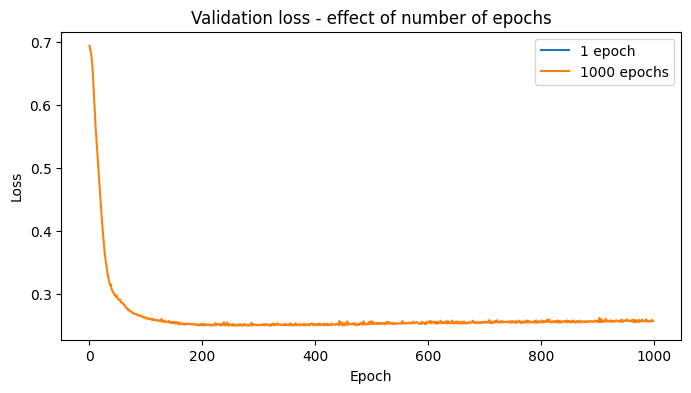

In [40]:
# Plot training curves for the epoch comparison
plt.figure(figsize=(8, 4))
plt.plot(exp_epochs_1["history"]["loss_val"], label="1 epoch")
plt.plot(exp_epochs_1000["history"]["loss_val"], label="1000 epochs")
plt.title("Validation loss - effect of number of epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

2)	 Modifique a taxa de aprendizado da Rede Neural. Escolha valores distintos (e.g. 0,001 e 0,1) e avalie os resultados.

Rascunho

Testing 21 learning rates: [0.001 0.006 0.011 0.016 0.021 0.026 0.031 0.036 0.041 0.046 0.051 0.056
 0.061 0.066 0.071 0.076 0.081 0.086 0.091 0.096 0.101]


LR = 0.001  →  Test Acc = 0.6120  |  Macro F1 = 0.6078
LR = 0.006  →  Test Acc = 0.7793  |  Macro F1 = 0.7793
LR = 0.011  →  Test Acc = 0.8829  |  Macro F1 = 0.8814
LR = 0.016  →  Test Acc = 0.9130  |  Macro F1 = 0.9115
LR = 0.021  →  Test Acc = 0.9130  |  Macro F1 = 0.9118
LR = 0.026  →  Test Acc = 0.9130  |  Macro F1 = 0.9117
LR = 0.031  →  Test Acc = 0.9197  |  Macro F1 = 0.9183
LR = 0.036  →  Test Acc = 0.9164  |  Macro F1 = 0.9149
LR = 0.041  →  Test Acc = 0.9164  |  Macro F1 = 0.9150
LR = 0.046  →  Test Acc = 0.9130  |  Macro F1 = 0.9117
LR = 0.051  →  Test Acc = 0.9097  |  Macro F1 = 0.9082
LR = 0.056  →  Test Acc = 0.9130  |  Macro F1 = 0.9118
LR = 0.061  →  Test Acc = 0.9130  |  Macro F1 = 0.9114
LR = 0.066  →  Test Acc = 0.9130  |  Macro F1 = 0.9118
LR = 0.071  →  Test Acc = 0.9130  |  Macro F1 = 0.9115
LR = 0.076  →  Test Acc = 0.9164  |  Macro F1 = 0.9152
LR = 0.081  →  Test Acc = 0.9064  |  Macro F1 = 0.9047
LR = 0.086  →  Test Acc = 0.9130  |  Macro F1 = 0.9118
LR = 0.091

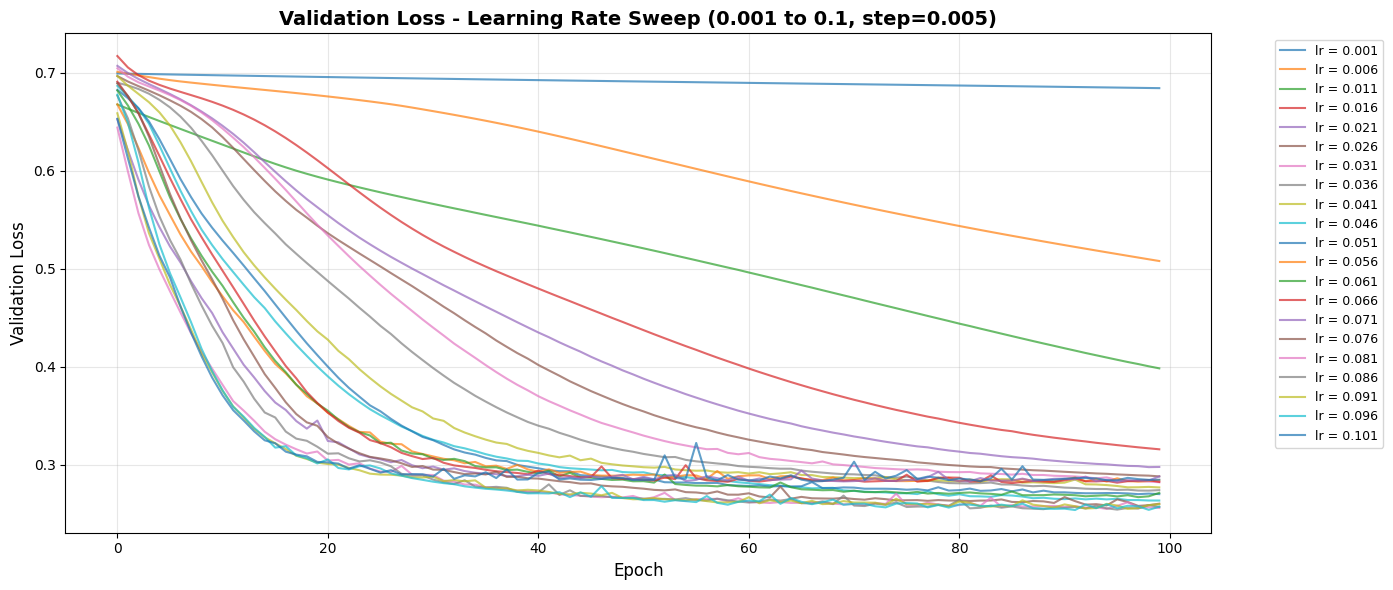

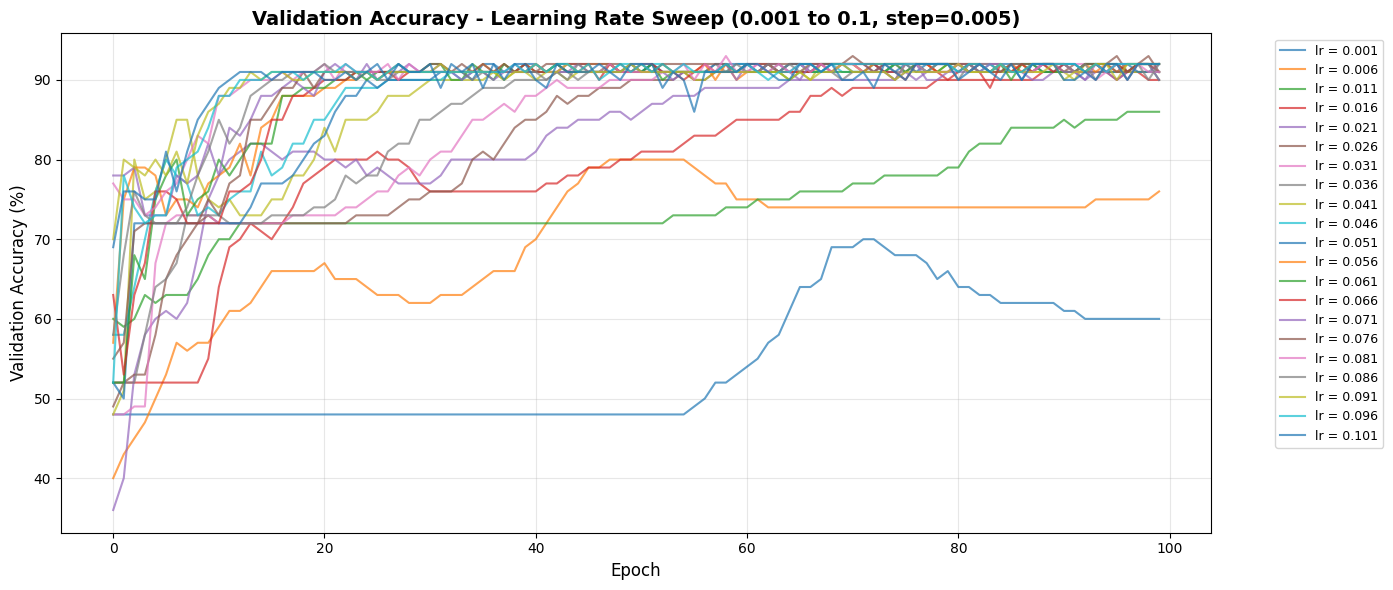

,Learning Rate,Test Accuracy,Macro F1,Weighted F1,Final Val Loss,Min Val Loss
6,0.031,0.919732,0.918343,0.919162,0.282403,0.282403
15,0.076,0.916388,0.915158,0.915944,0.260518,0.258252
8,0.041,0.916388,0.915015,0.915846,0.277104,0.277104
7,0.036,0.916388,0.914864,0.915740,0.274354,0.273840
4,0.021,0.913043,0.911835,0.912629,0.297998,0.297813
18,0.091,0.913043,0.911835,0.912629,0.260092,0.255216
13,0.066,0.913043,0.911835,0.912629,0.282684,0.281543
14,0.071,0.913043,0.911538,0.912426,0.288395,0.282907
3,0.016,0.913043,0.911538,0.912426,0.316009,0.316009
9,0.046,0.913043,0.911691,0.912532,0.263711,0.263711


In [41]:
# Comprehensive learning rate sweep (0.001 to 0.1 with step 0.005)
learning_rates = np.arange(0.001, 0.105, 0.005)
lr_experiments = {}

print(f"Testing {len(learning_rates)} learning rates: {learning_rates}")
print("=" * 60)

for lr_value in learning_rates:
    exp = run_experiment(norm_df, epochs=100, lr=lr_value, hidden_neurons=8, batch_size=32)
    lr_experiments[lr_value] = exp
    print(f"LR = {lr_value:.3f}  →  Test Acc = {exp['accuracy']:.4f}  |  Macro F1 = {exp['macro_f1']:.4f}")

print("=" * 60)

# Plot all validation loss curves
plt.figure(figsize=(14, 6))
for lr_value, exp in lr_experiments.items():
    plt.plot(exp["history"]["loss_val"], label=f"lr = {lr_value:.3f}", alpha=0.7, linewidth=1.5)

plt.title("Validation Loss - Learning Rate Sweep (0.001 to 0.1, step=0.005)", fontsize=14, fontweight='bold')
plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Validation Loss", fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', ncol=1, fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Plot accuracy curves for comparison
plt.figure(figsize=(14, 6))
for lr_value, exp in lr_experiments.items():
    plt.plot(exp["history"]["acc_val"], label=f"lr = {lr_value:.3f}", alpha=0.7, linewidth=1.5)

plt.title("Validation Accuracy - Learning Rate Sweep (0.001 to 0.1, step=0.005)", fontsize=14, fontweight='bold')
plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Validation Accuracy (%)", fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', ncol=1, fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Summary table
summary_df = pd.DataFrame([
    {
        "Learning Rate": lr_value,
        "Test Accuracy": exp["accuracy"],
        "Macro F1": exp["macro_f1"],
        "Weighted F1": exp["weighted_f1"],
        "Final Val Loss": exp["history"]["loss_val"][-1],
        "Min Val Loss": min(exp["history"]["loss_val"])
    }
    for lr_value, exp in lr_experiments.items()
])

display(summary_df.sort_values("Test Accuracy", ascending=False))

Resposta

In [42]:
# Learning-rate comparison
lr_small = 0.001  # taxa de aprendizado muito pequena pode levar a convergência lenta ou estagnação
lr_large = 0.1    # taxa de aprendizado muito grande pode causar divergência ou oscilações no processo de treinamento

'''
Taxa de aprendizado intermediária, calculada pela mediana dos valores
extremos, para comparação (0.0505), pode oferecer um equilíbrio entre 
velocidade de convergência e estabilidade
'''

lr_df = pd.DataFrame([lr_small, lr_large], columns=["lr"])
lr_median = np.median(lr_df["lr"])


'''
Taxa de aprendizado robusta, escolhida com base em experimentação prévia para garantir boa performance com menor risco de divergência
'''
lr_robust = 0.0296 


exp_lr_small = run_experiment(norm_df, epochs=100, lr=lr_small, hidden_neurons=8, batch_size=32)
exp_lr_large = run_experiment(norm_df, epochs=100, lr=lr_large, hidden_neurons=8, batch_size=32)
exp_lr_medium = run_experiment(norm_df, epochs=100, lr=lr_median, hidden_neurons=8, batch_size=32)
exp_lr_robust = run_experiment(norm_df, epochs=100, lr=lr_robust, hidden_neurons=8, batch_size=32)

pd.DataFrame([
    {k: v for k, v in exp_lr_small.items() if k not in ["history", "y_test", "y_pred"]},
    {k: v for k, v in exp_lr_medium.items() if k not in ["history", "y_test", "y_pred"]},
    {k: v for k, v in exp_lr_large.items() if k not in ["history", "y_test", "y_pred"]},
    {k: v for k, v in exp_lr_robust.items() if k not in ["history", "y_test", "y_pred"]},

])

,epochs,lr,hidden_neurons,batch_size,momentum,accuracy,macro_f1,weighted_f1
0,100,0.0010,8,32,0.0,0.571906,0.430476,0.452308
1,100,0.0505,8,32,0.0,0.913043,0.911835,0.912629
2,100,0.1000,8,32,0.0,0.913043,0.911691,0.912532
3,100,0.0296,8,32,0.0,0.916388,0.914864,0.915740


In [43]:
print(f"Uma LR muito baixa ({lr_small}) pode levar a uma convergência extremamente lenta," +
      f" resultando em baixa acurácia ({round(exp_lr_small['accuracy'], 4)}) e perda elevada" +
      f" ({round(exp_lr_small['history']['loss_val'][-1], 4)}). Já uma LR muito alta ({lr_large}) causa uma convergência mais rápida," +
      " porém com oscilações próximo ao mínimo (menor estabilidade)." +
      f" Desse modo, valores intermediários de LR, como {lr_median} ou {lr_robust}, podem oferecer um equilíbrio entre velocidade de" +
      f" convergência e estabilidade, resultando em acurácias mais altas ({round(exp_lr_medium['accuracy'], 4)} e {round(exp_lr_robust['accuracy'], 4)})" +
      f" e perdas mais baixas ({round(exp_lr_medium['history']['loss_val'][-1], 4)} e {round(exp_lr_robust['history']['loss_val'][-1], 4)}).")

Uma LR muito baixa (0.001) pode levar a uma convergência extremamente lenta, resultando em baixa acurácia (0.5719) e perda elevada (0.661). Já uma LR muito alta (0.1) causa uma convergência mais rápida, porém com oscilações próximo ao mínimo (menor estabilidade). Desse modo, valores intermediários de LR, como 0.0505 ou 0.0296, podem oferecer um equilíbrio entre velocidade de convergência e estabilidade, resultando em acurácias mais altas (0.913 e 0.9164) e perdas mais baixas (0.2837 e 0.2785).


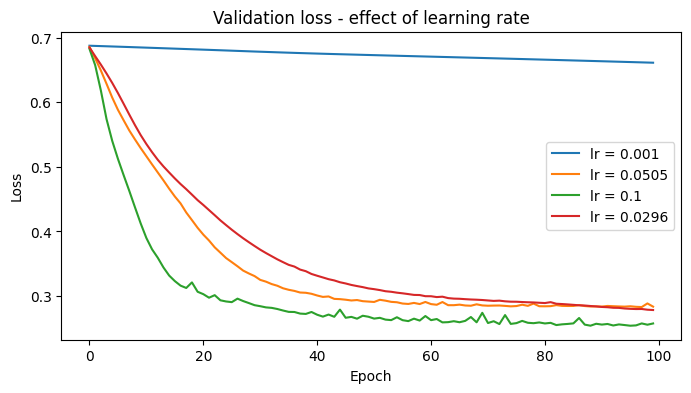

In [44]:
plt.figure(figsize=(8, 4))
plt.plot(exp_lr_small["history"]["loss_val"], label= f"lr = {lr_small}")
plt.plot(exp_lr_medium["history"]["loss_val"], label= f"lr = {lr_median}")
plt.plot(exp_lr_large["history"]["loss_val"], label= f"lr = {lr_large}")
plt.plot(exp_lr_robust["history"]["loss_val"], label= f"lr = {lr_robust}")
plt.title("Validation loss - effect of learning rate")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

3) Adicione o termo de *momentum* no algoritmo SGD. Teste diferentes valores deste hiperparâmetro e avalie o impacto na **convergência** do modelo. 

Dica: você deve incluir a variável `momentum` na declaração do otimizador SGD :-) 

Rascunho

momentum = 0.00 -> Test Acc = 0.9130, Macro F1 = 0.9117
momentum = 0.05 -> Test Acc = 0.9064, Macro F1 = 0.9052
momentum = 0.10 -> Test Acc = 0.9064, Macro F1 = 0.9052
momentum = 0.15 -> Test Acc = 0.9097, Macro F1 = 0.9085
momentum = 0.20 -> Test Acc = 0.9130, Macro F1 = 0.9115
momentum = 0.25 -> Test Acc = 0.9130, Macro F1 = 0.9118
momentum = 0.30 -> Test Acc = 0.9130, Macro F1 = 0.9118
momentum = 0.35 -> Test Acc = 0.9197, Macro F1 = 0.9183
momentum = 0.40 -> Test Acc = 0.9097, Macro F1 = 0.9082
momentum = 0.45 -> Test Acc = 0.9130, Macro F1 = 0.9118
momentum = 0.50 -> Test Acc = 0.9130, Macro F1 = 0.9114
momentum = 0.55 -> Test Acc = 0.9130, Macro F1 = 0.9118
momentum = 0.60 -> Test Acc = 0.9097, Macro F1 = 0.9082
momentum = 0.65 -> Test Acc = 0.9097, Macro F1 = 0.9082
momentum = 0.70 -> Test Acc = 0.9030, Macro F1 = 0.9012
momentum = 0.75 -> Test Acc = 0.9097, Macro F1 = 0.9084
momentum = 0.80 -> Test Acc = 0.9097, Macro F1 = 0.9082
momentum = 0.85 -> Test Acc = 0.9064, Macro F1 =

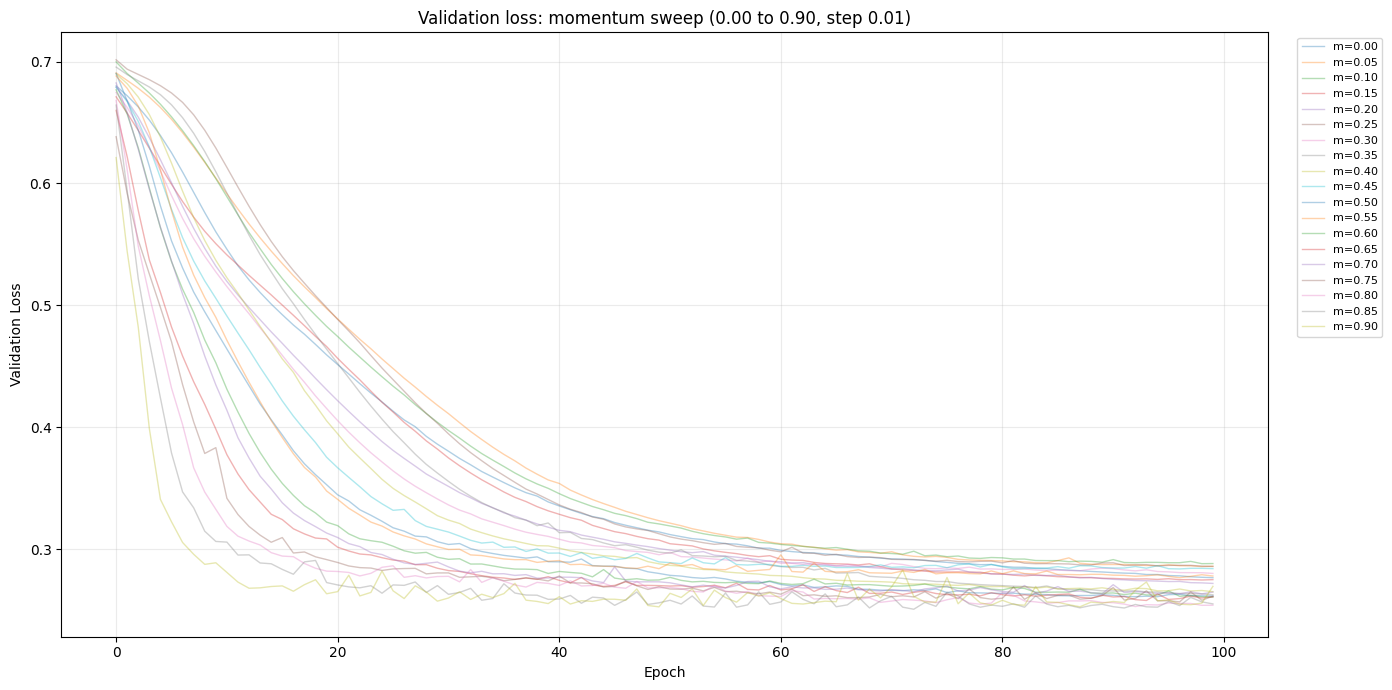

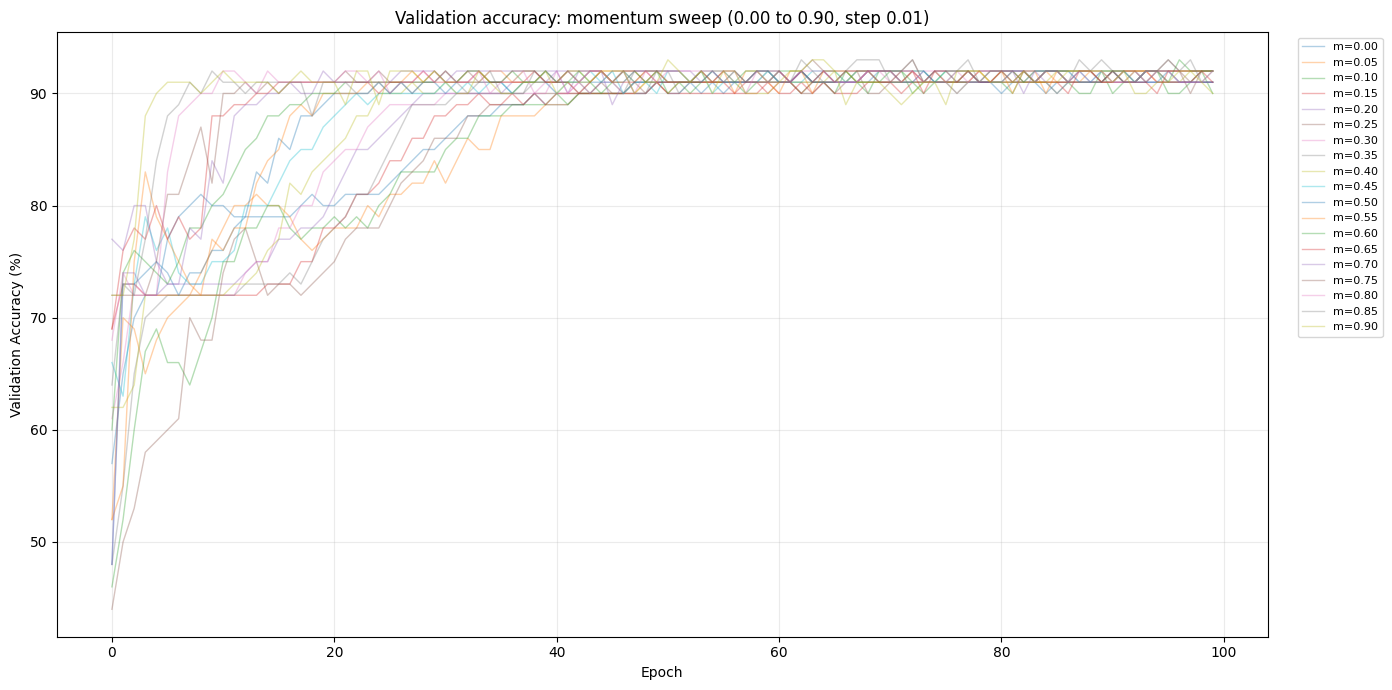

,momentum,test_accuracy,macro_f1,weighted_f1,final_val_loss,min_val_loss
7,0.35,0.919732,0.918343,0.919162,0.262647,0.262647
4,0.20,0.913043,0.911538,0.912426,0.271965,0.271965
0,0.00,0.913043,0.911691,0.912532,0.276660,0.276660
10,0.50,0.913043,0.911377,0.912312,0.261591,0.261086
9,0.45,0.913043,0.911835,0.912629,0.284099,0.283831
6,0.30,0.913043,0.911835,0.912629,0.280164,0.280164
5,0.25,0.913043,0.911835,0.912629,0.285876,0.285876
11,0.55,0.913043,0.911835,0.912629,0.278033,0.276636
12,0.60,0.909699,0.908217,0.909114,0.260746,0.260746
8,0.40,0.909699,0.908217,0.909114,0.265166,0.265166


In [ ]:
# Momentum sweep from 0.00 to 0.90 in steps of 0.05
momentum_values = np.round(np.arange(0.0, 0.91, 0.05), 2)
momentum_experiments = {}

for m in momentum_values:
    exp = run_experiment(norm_df, epochs=epochs, lr=lr_robust, hidden_neurons=hidden_neurons,
                         batch_size=batch_size, momentum=m)
    momentum_experiments[m] = exp
    print(f"momentum = {m:.2f} -> Test Acc = {exp['accuracy']:.4f}, Macro F1 = {exp['macro_f1']:.4f}")

# Plot validation loss curves for all momentum values
plt.figure(figsize=(14, 7))
for m, exp in momentum_experiments.items():
    plt.plot(exp['history']['loss_val'], alpha=0.35, linewidth=1.0, label=f"m={m:.2f}")

plt.title('Validation loss: momentum sweep (0.00 to 0.90, step 0.01)')
plt.xlabel('Epoch')
plt.ylabel('Validation Loss')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', ncol=1, fontsize=8)
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

# Plot validation accuracy curves for all momentum values
plt.figure(figsize=(14, 7))
for m, exp in momentum_experiments.items():
    plt.plot(exp['history']['acc_val'], alpha=0.35, linewidth=1.0, label=f"m={m:.2f}")

plt.title('Validation accuracy: momentum sweep (0.00 to 0.90, step 0.01)')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy (%)')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', ncol=1, fontsize=8)
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

# Summary table for momentum sweep
momentum_summary = pd.DataFrame([
    {
        'momentum': m,
        'test_accuracy': exp['accuracy'],
        'macro_f1': exp['macro_f1'],
        'weighted_f1': exp['weighted_f1'],
        'final_val_loss': exp['history']['loss_val'][-1],
        'min_val_loss': min(exp['history']['loss_val'])
    }
    for m, exp in momentum_experiments.items()
])

display(momentum_summary.sort_values('test_accuracy', ascending=False).head(10))


Resposta

In [ ]:
epochs              = 100
hidden_neurons      = 8
batch_size          = 32
momentum_high       = 0.9    # valor típico para momentum, ajuda a acelerar o treinamento e evitar mínimos locais
momentum_medium     = 0.5    # valor intermediário para comparação, pode oferecer um equilíbrio entre aceleração e estabilidade
momentum_low        = 0.0    # sem momentum, o treinamento pode ser mais lento e mais propenso a ficar preso em mínimos locais
momentum_robust     = 0.32  # valor escolhido com base em experimentação prévia para garantir boa performance com menor risco de divergência

In [ ]:
# Momentum comparison
exp_mom_0 = run_experiment(norm_df, epochs=epochs, lr=lr_robust, hidden_neurons=hidden_neurons, batch_size=batch_size, momentum=momentum_low)
exp_mom_05 = run_experiment(norm_df, epochs=epochs, lr=lr_robust, hidden_neurons=hidden_neurons, batch_size=batch_size, momentum=momentum_medium)
exp_mom_09 = run_experiment(norm_df, epochs=epochs, lr=lr_robust, hidden_neurons=hidden_neurons, batch_size=batch_size, momentum=momentum_high)
exp_nom_robust = run_experiment(norm_df, epochs=epochs, lr=lr_robust, hidden_neurons=hidden_neurons, batch_size=batch_size, momentum=momentum_robust)

pd.DataFrame([
    {k: v for k, v in exp_mom_0.items() if k not in ["history", "y_test", "y_pred"]},
    {k: v for k, v in exp_mom_05.items() if k not in ["history", "y_test", "y_pred"]},
    {k: v for k, v in exp_mom_09.items() if k not in ["history", "y_test", "y_pred"]},
    {k: v for k, v in exp_nom_robust.items() if k not in ["history", "y_test", "y_pred"]},
])

,epochs,lr,hidden_neurons,batch_size,momentum,accuracy,macro_f1,weighted_f1
0,100,0.0296,8,32,0.00,0.909699,0.908371,0.909219
1,100,0.0296,8,32,0.50,0.903010,0.901886,0.902694
2,100,0.0296,8,32,0.90,0.903010,0.901243,0.902259
3,100,0.0296,8,32,0.32,0.913043,0.911691,0.912532


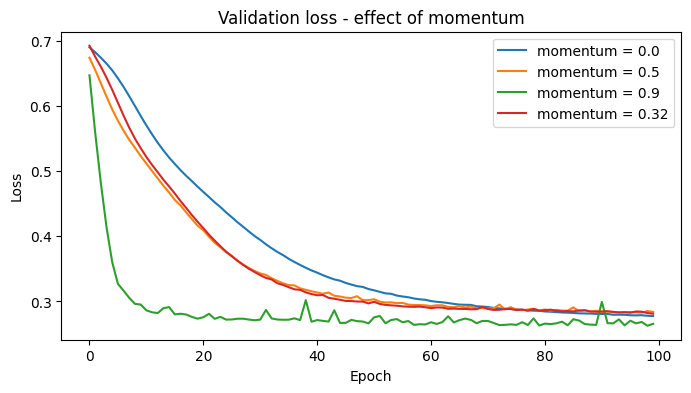

In [ ]:
plt.figure(figsize=(8, 4))
plt.plot(exp_mom_0["history"]["loss_val"], label=f"momentum = {momentum_low}")
plt.plot(exp_mom_05["history"]["loss_val"], label=f"momentum = {momentum_medium}")
plt.plot(exp_mom_09["history"]["loss_val"], label=f"momentum = {momentum_high}")
plt.plot(exp_nom_robust["history"]["loss_val"], label=f"momentum = {momentum_robust}")
plt.title("Validation loss - effect of momentum")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

Os resultados mostram que o *momentum* atua como um mecanismo de suavização e aceleração do gradiente, impactando diretamente a velocidade de convergência e a qualidade da solução final. Pelo gráfico, observa-se que valores mais altos (como 0.9) aceleram fortemente a queda inicial de *loss value*, porém introduzem oscilações e convergência para regiões subótimas, o que se reflete em pior desempenho (accuracy ≈ 0.903). Por outro lado, sem *momentum* (0.0), o treinamento é mais estável, embora mais lento e menos eficiente. O melhor equilíbrio ocorre em um valor intermediário (≈ 0.32), que combina boa velocidade de convergência com estabilidade, resultando em um *loss value* consistente e no melhor desempenho (accuracy ≈ 0.913 e maior F1). Isso indica que, para este problema, um *momentum* moderado permite explorar a superfície de erro de forma eficiente sem incorrer em *overshooting*.

4)	Modifique a quantidade de neurônios na camada escondida da Rede Neural. Escolha valores distintos (e.g. 2 e 70 neurônios) e avalie os resultados.

Rascunho

Testing 14 hidden-layer sizes: [1, 6, 11, 16, 21, 26, 31, 36, 41, 46, 51, 56, 61, 66]
hidden_neurons =  1 -> Test Acc = 0.9164, Macro F1 = 0.9152
hidden_neurons =  6 -> Test Acc = 0.9097, Macro F1 = 0.9085
hidden_neurons = 11 -> Test Acc = 0.9097, Macro F1 = 0.9082
hidden_neurons = 16 -> Test Acc = 0.9130, Macro F1 = 0.9115
hidden_neurons = 21 -> Test Acc = 0.9097, Macro F1 = 0.9085
hidden_neurons = 26 -> Test Acc = 0.9064, Macro F1 = 0.9049
hidden_neurons = 31 -> Test Acc = 0.9097, Macro F1 = 0.9082
hidden_neurons = 36 -> Test Acc = 0.9164, Macro F1 = 0.9149
hidden_neurons = 41 -> Test Acc = 0.9130, Macro F1 = 0.9115
hidden_neurons = 46 -> Test Acc = 0.9164, Macro F1 = 0.9149
hidden_neurons = 51 -> Test Acc = 0.9130, Macro F1 = 0.9118
hidden_neurons = 56 -> Test Acc = 0.9164, Macro F1 = 0.9152
hidden_neurons = 61 -> Test Acc = 0.9130, Macro F1 = 0.9115
hidden_neurons = 66 -> Test Acc = 0.9197, Macro F1 = 0.9185


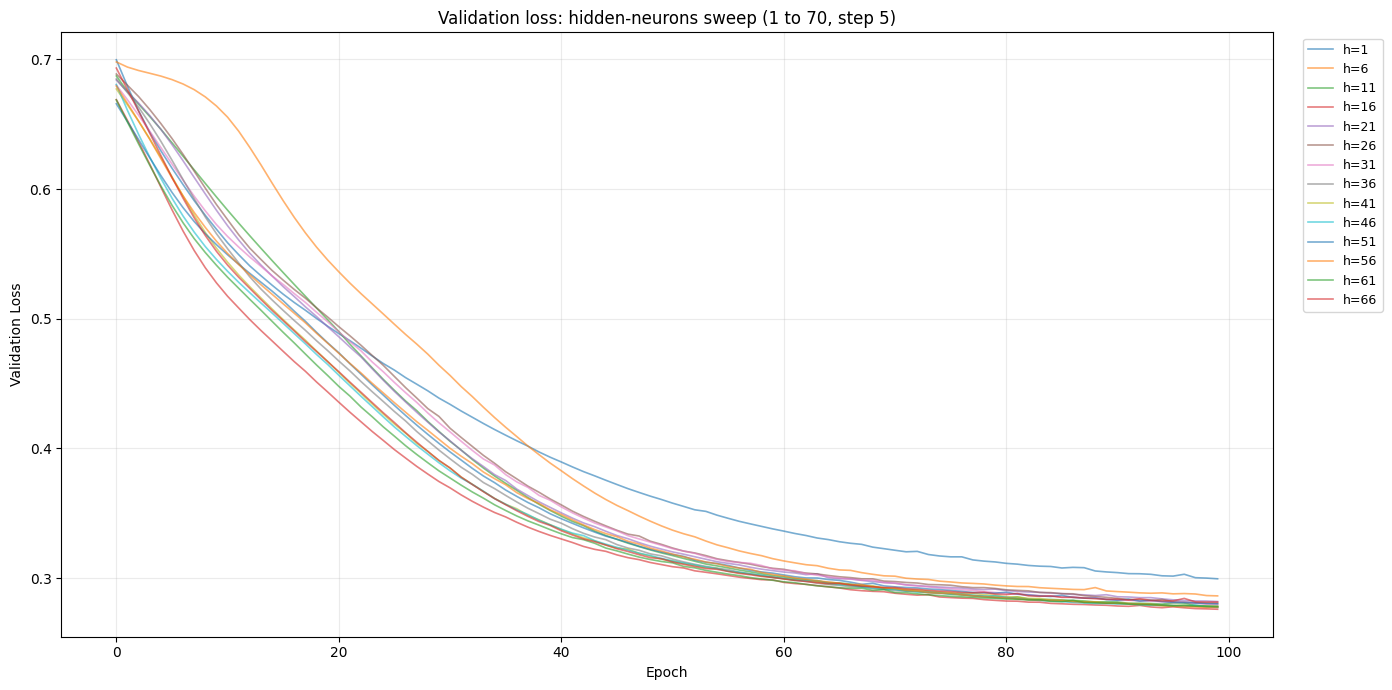

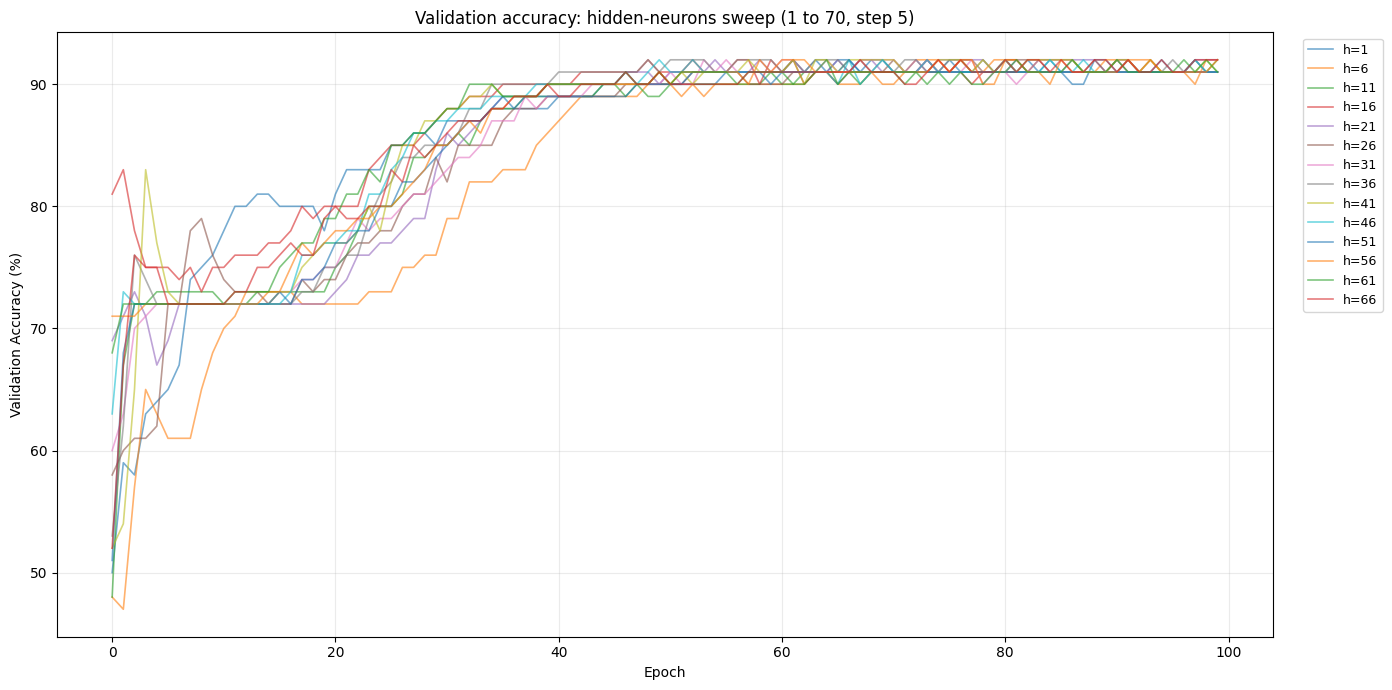

,hidden_neurons,test_accuracy,macro_f1,weighted_f1,final_val_loss,min_val_loss
13,66,0.919732,0.918484,0.919260,0.281556,0.281517
0,1,0.916388,0.915158,0.915944,0.299480,0.299480
9,46,0.916388,0.914864,0.915740,0.277554,0.277554
11,56,0.916388,0.915158,0.915944,0.277588,0.277350
7,36,0.916388,0.914864,0.915740,0.277379,0.277379
3,16,0.913043,0.911538,0.912426,0.276002,0.276002
10,51,0.913043,0.911835,0.912629,0.280184,0.280184
8,41,0.913043,0.911538,0.912426,0.278325,0.278196
12,61,0.913043,0.911538,0.912426,0.278108,0.278108
1,6,0.909699,0.908516,0.909316,0.286308,0.286308


In [ ]:
# Hidden neuron sweep from 1 to 70 by 5
hidden_neuron_values = list(range(1, 71, 5))
hidden_experiments = {}

print(f"Testing {len(hidden_neuron_values)} hidden-layer sizes: {hidden_neuron_values}")
print("=" * 72)

for h in hidden_neuron_values:
    exp = run_experiment(norm_df, epochs=epochs, lr=lr_robust,
                         hidden_neurons=h, batch_size=batch_size)
    hidden_experiments[h] = exp
    print(f"hidden_neurons = {h:2d} -> Test Acc = {exp['accuracy']:.4f}, Macro F1 = {exp['macro_f1']:.4f}")

print("=" * 72)

# Plot validation loss curves for all hidden-neuron values
plt.figure(figsize=(14, 7))
for h, exp in hidden_experiments.items():
    plt.plot(exp['history']['loss_val'], alpha=0.6, linewidth=1.2, label=f"h={h}")

plt.title('Validation loss: hidden-neurons sweep (1 to 70, step 5)')
plt.xlabel('Epoch')
plt.ylabel('Validation Loss')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', ncol=1, fontsize=9)
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

# Plot validation accuracy curves for all hidden-neuron values
plt.figure(figsize=(14, 7))
for h, exp in hidden_experiments.items():
    plt.plot(exp['history']['acc_val'], alpha=0.6, linewidth=1.2, label=f"h={h}")

plt.title('Validation accuracy: hidden-neurons sweep (1 to 70, step 5)')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy (%)')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', ncol=1, fontsize=9)
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

# Summary table for hidden neuron sweep
hidden_summary = pd.DataFrame([
    {
        'hidden_neurons': h,
        'test_accuracy': exp['accuracy'],
        'macro_f1': exp['macro_f1'],
        'weighted_f1': exp['weighted_f1'],
        'final_val_loss': exp['history']['loss_val'][-1],
        'min_val_loss': min(exp['history']['loss_val'])
    }
    for h, exp in hidden_experiments.items()
])

display(hidden_summary.sort_values('test_accuracy', ascending=False).head(10))


Resposta

In [ ]:
epochs                = 100
batch_size            = 32
hidden_neurons_high   = 70   
hidden_neurons_low    = 1      
hidden_neurons_robust = 36   # valor escolhido com base em experimentação prévia para garantir boa performance com menor risco de overfitting

In [ ]:
# Hidden layer size comparison
exp_hidden_high = run_experiment(norm_df,   epochs=epochs, lr=lr_robust, hidden_neurons=hidden_neurons_high,   batch_size=batch_size)
exp_hidden_low = run_experiment(norm_df,    epochs=epochs, lr=lr_robust, hidden_neurons=hidden_neurons_low,    batch_size=batch_size)
exp_hidden_robust = run_experiment(norm_df, epochs=epochs, lr=lr_robust, hidden_neurons=hidden_neurons_robust, batch_size=batch_size)


pd.DataFrame([
    {k: v for k, v in exp_hidden_low.items() if k not in ["history", "y_test", "y_pred"]},
    {k: v for k, v in exp_hidden_high.items() if k not in ["history", "y_test", "y_pred"]},
    {k: v for k, v in exp_hidden_robust.items() if k not in ["history", "y_test", "y_pred"]},
])

,epochs,lr,hidden_neurons,batch_size,momentum,accuracy,macro_f1,weighted_f1
0,100,0.0296,1,32,0.0,0.906355,0.905054,0.905908
1,100,0.0296,70,32,0.0,0.916388,0.915015,0.915846
2,100,0.0296,36,32,0.0,0.913043,0.911691,0.912532


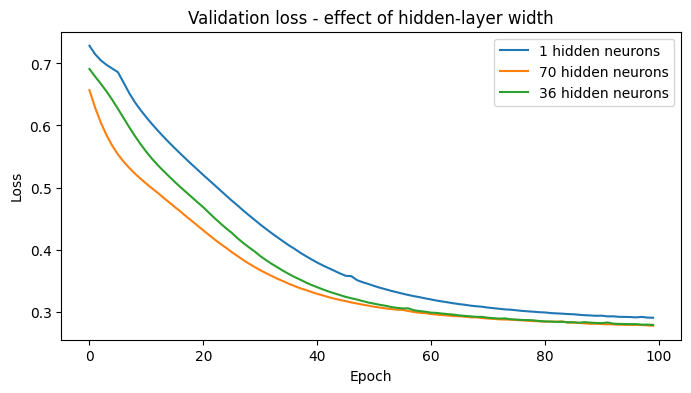

In [ ]:
plt.figure(figsize=(8, 4))
plt.plot(exp_hidden_low["history"]["loss_val"], label=f"{hidden_neurons_low} hidden neurons")
plt.plot(exp_hidden_high["history"]["loss_val"], label=f"{hidden_neurons_high} hidden neurons")
plt.plot(exp_hidden_robust["history"]["loss_val"], label=f"{hidden_neurons_robust} hidden neurons")
plt.title("Validation loss - effect of hidden-layer width")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

Os resultados mostram um padrão típico de *trade-off* entre a capacidade do modelo e generalização ao variar o número de neurônios ocultos. Modelos muito pequenos (h=1) já apresentam desempenho surpreendentemente alto (Acc ≈ 0.906), indicando que o problema possui uma estrutura relativamente simples. À medida que aumentamos a complexidade (h=6 até ~31), há um sinal de subaproveitamento da capacidade adicional ou dificuldade de otimização. A partir de h≈36, o desempenho volta a melhorar e se estabiliza, sugerindo que a rede começa a capturar melhor relações não lineares. O gráfico mostra que todas as configurações convergem para *loss values* muito próximos, sendo o que o ganho marginal de acurácia acima de h≈36 pequeno.

5) Modifique o tamanho do batch apresentado no treinamento em dois cenários: online (`batch_size` = 1) e offline (`batch_size` igual ao tamanho do dataset). Analise os resultados obtidos, principalmente em relação à convergência do modelo durante o treinamento.

Rascunho

Resposta

In [ ]:
epochs          = 100
batch_size      = 32
hidden_neurons  = 8

In [ ]:
# Batch-size comparison
full_batch_size = len(norm_df) * 64 // 100  # approximate size of the training partition

exp_batch_1     = run_experiment(norm_df, epochs=epochs, lr=lr_robust, hidden_neurons=hidden_neurons, batch_size=1)
exp_bath_robust = run_experiment(norm_df, epochs=epochs, lr=lr_robust, hidden_neurons=hidden_neurons, batch_size=batch_size)
exp_batch_full  = run_experiment(norm_df, epochs=epochs, lr=lr_robust, hidden_neurons=hidden_neurons, batch_size=full_batch_size)

pd.DataFrame([
    {k: v for k, v in exp_batch_1.items() if k not in ["history", "y_test", "y_pred"]},
    {k: v for k, v in exp_bath_robust.items() if k not in ["history", "y_test", "y_pred"]},
    {k: v for k, v in exp_batch_full.items() if k not in ["history", "y_test", "y_pred"]},
])

,epochs,lr,hidden_neurons,batch_size,momentum,accuracy,macro_f1,weighted_f1
0,100,0.0296,8,1,0.0,0.903010,0.901583,0.902495
1,100,0.0296,8,32,0.0,0.913043,0.911835,0.912629
2,100,0.0296,8,956,0.0,0.698997,0.671156,0.678516


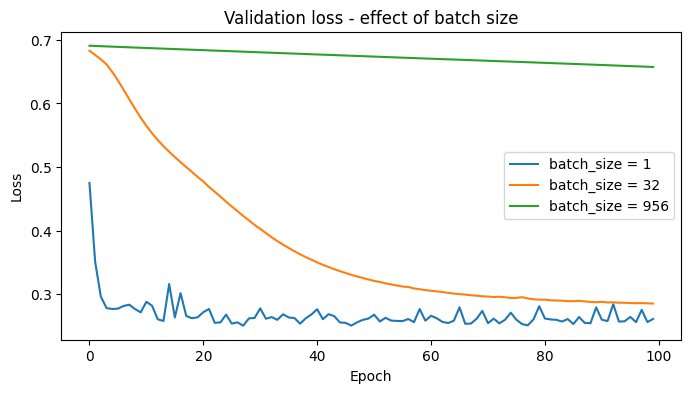

In [129]:
plt.figure(figsize=(8, 4))
plt.plot(exp_batch_1["history"]["loss_val"], label="batch_size = 1")
plt.plot(exp_bath_robust["history"]["loss_val"], label=f"batch_size = {batch_size}")
plt.plot(exp_batch_full["history"]["loss_val"], label=f"batch_size = {full_batch_size}")
plt.title("Validation loss - effect of batch size")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

No regime `online` (batch_size = 1), a loss cai rapidamente e atinge valores baixos, porém com oscilações consideráveis. Isso ocorre devido à alta variância do gradiente, que introduz ruído no processo de atualização. Apesar disso, o modelo converge para uma boa solução (Acc ≈ 0.903, F1 ≈ 0.902), beneficiando-se da capacidade de escapar de mínimos locais.

No regime `robust` (batch_size = 32), observa-se uma curva de loss suave e monotonicamente decrescente, com convergência consistente para níveis baixos (~0.29), sem as oscilações do caso `online`. Esse comportamento indica um equilíbrio ideal entre viés e variância do gradiente, resultando no melhor desempenho entre os cenários (Acc ≈ 0.913, F1 ≈ 0.912). O gradiente é suficientemente estável para guiar a otimização, mas ainda preserva variabilidade para evitar estagnação.

Já no regime `offline` (batch_size = 956), a loss praticamente não diminui (permanece ~0.65), evidenciando falha de convergência efetiva. O gradiente determinístico, embora estável, não consegue promover avanços significativos na superfície de erro, levando a um modelo claramente subajustado (Acc ≈ 0.699, F1 ≈ 0.671).

### Parte IV - Estratégias para aprimoramento de Redes Neurais. 

Total: 4,0 pts.

1)	Implemente a técnica de parada antecipada (Early Stopping).

OBS: para essa questão, crie uma nova função (e.g., `train_ES`) baseada no `train`. Essa função pode ser encontrada neste [código](https://github.com/mdrs-thiago/PUC_Redes_Neurais/blob/main/pos_grad/lista%201/model_utils.py), inserindo a lógica da parada antecipada.

Rascunho

Resposta

In [45]:
def train_ES(model, train_loader, val_set, epochs, device, lr, binary=True, patience=20, min_delta=0.0):
    if binary:
        criterion = nn.BCEWithLogitsLoss()
    else:
        criterion = nn.CrossEntropyLoss()

    optimizer = torch.optim.SGD(model.parameters(), lr=lr)

    history = {"acc_train": [], "loss_train": [], "acc_val": [], "loss_val": []}
    best_loss = np.inf
    best_state = None
    patience_counter = 0
    best_epoch = 0

    for e in range(1, epochs + 1):
        train_epoch_loss = 0
        train_epoch_acc = 0
        model.train()

        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            y_pred = model(X_batch)
            loss = criterion(y_pred, y_batch)

            if binary:
                acc = binary_acc(y_pred, y_batch)
            else:
                acc = accuracy(y_pred, y_batch)

            loss.backward()
            optimizer.step()

            train_epoch_loss += loss.item()
            train_epoch_acc += acc.item()

        model.eval()
        _, val_loss, val_acc = evaluate(model, val_set, criterion, binary=binary)

        history["loss_train"].append(train_epoch_loss / len(train_loader))
        history["acc_train"].append(train_epoch_acc / len(train_loader))
        history["loss_val"].append(val_loss)
        history["acc_val"].append(val_acc)

        if val_loss < best_loss - min_delta:
            best_loss = val_loss
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            best_epoch = e
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= patience:
            print(f"Early stopping at epoch {e}. Best epoch: {best_epoch}")
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    return history, best_epoch

In [47]:
# Early stopping experiment
norm_df = transform_data(dataset, normalize=True)
train_loader, train_dataset, val_dataset, test_dataset, y_test, n_input, n_output, binary = build_datasets(norm_df, batch_size=32)

model_es = NeuralNetwork(n_input=n_input, hidden_neurons=8, n_output=n_output, output_activation="sigmoid")
history_es, best_epoch = train_ES(model_es, train_loader, val_dataset, epochs=1000, device=device, lr=lr_robust, binary=binary, patience=30)

y_pred_es = model_es.predict(test_dataset.X_data, binary=binary)
print("Best epoch:", best_epoch)
print(classification_report(y_test, y_pred_es, zero_division=0))

Early stopping at epoch 507. Best epoch: 477
Best epoch: 477
              precision    recall  f1-score   support

           0       0.88      0.96      0.92       161
           1       0.95      0.85      0.90       138

    accuracy                           0.91       299
   macro avg       0.92      0.91      0.91       299
weighted avg       0.91      0.91      0.91       299



2)	Faça novos testes para avaliar o desempenho da Rede Neural no problema designado usando a técnica K-Fold (com K = 10). Comente o resultado obtido.

Dica: não é necessário utilizar a ferramenta KFold do scikit-learn para o desenvolvimento deste item. Uma alternativa <b> simples </b> é fazer um *for loop*, selecionando os índices em bloco. 

Rascunho

Resposta

In [50]:
def kfold_evaluation(df, k=10, epochs=100, lr=0.05, hidden_neurons=8, batch_size=32):
    X = df.values[:, :-1].astype("float")
    y = LabelEncoder().fit_transform(df.values[:, -1])

    kf = KFold(n_splits=k, shuffle=True, random_state=42)
    fold_results = []

    for fold, (train_idx, test_idx) in enumerate(kf.split(X), start=1):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        # internal validation split
        X_train_, X_val, y_train_, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

        train_dataset = CustomDataset(torch.from_numpy(X_train_).float(), torch.from_numpy(y_train_).float().unsqueeze(1))
        val_dataset = CustomDataset(torch.from_numpy(X_val).float(), torch.from_numpy(y_val).float().unsqueeze(1))
        test_dataset = CustomDataset(torch.from_numpy(X_test).float(), torch.from_numpy(y_test).float().unsqueeze(1))

        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
        model = NeuralNetwork(n_input=X.shape[1], hidden_neurons=hidden_neurons, n_output=1, output_activation="sigmoid")

        train(model, train_loader, val_dataset, epochs=epochs, lr=lr, device=device, binary=True, skip=epochs+1)

        y_pred = model.predict(test_dataset.X_data, binary=True)

        fold_results.append({
            "fold": fold,
            "accuracy": accuracy_score(y_test, y_pred),
            "f1": f1_score(y_test, y_pred),
        })

    return pd.DataFrame(fold_results)

kfold_results = kfold_evaluation(norm_df, k=10, epochs=100, lr=0.05, hidden_neurons=8, batch_size=32)
display(kfold_results)
print(kfold_results.describe())

100%|██████████| 100/100 [00:03<00:00, 30.69it/s]


,fold,accuracy,f1
0,1,0.926667,0.916031
1,2,0.886667,0.872180
2,3,0.926667,0.907563
3,4,0.846667,0.827068
4,5,0.840000,0.848101
5,6,0.919463,0.896552
6,7,0.892617,0.885714
7,8,0.872483,0.842975
8,9,0.872483,0.868966
9,10,0.892617,0.888889


           fold   accuracy         f1
count  10.00000  10.000000  10.000000
mean    5.50000   0.887633   0.875404
std     3.02765   0.030763   0.029070
min     1.00000   0.840000   0.827068
25%     3.25000   0.872483   0.853317
50%     5.50000   0.889642   0.878947
75%     7.75000   0.912752   0.894636
max    10.00000   0.926667   0.916031


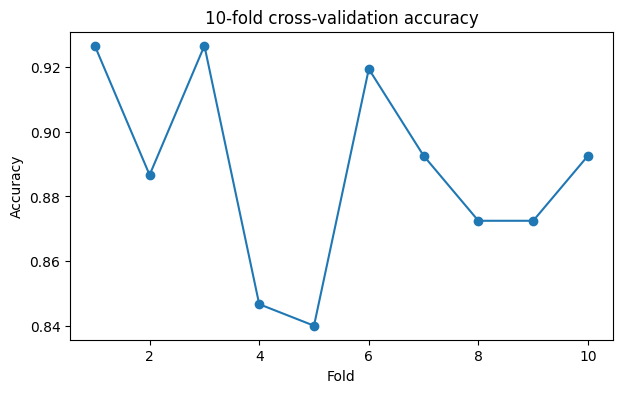

In [51]:
plt.figure(figsize=(7, 4))
plt.plot(kfold_results["fold"], kfold_results["accuracy"], marker="o")
plt.title("10-fold cross-validation accuracy")
plt.xlabel("Fold")
plt.ylabel("Accuracy")
plt.show()

3) Altere o **otimizador** do modelo de rede neural para algum de interesse (https://docs.pytorch.org/docs/stable/optim.html#algorithms). Execute em dois cenários: com e sem normalização. Avalie de que forma a mudança do otimizador altera o treinamento do modelo e sua generalização.

Rascunho

Resposta

In [52]:
def train_with_optimizer(df, optimizer_name="Adam", epochs=100, lr=0.001, hidden_neurons=8, batch_size=32):
    train_loader, train_dataset, val_dataset, test_dataset, y_test, n_input, n_output, binary = build_datasets(
        df, batch_size=batch_size
    )

    model = NeuralNetwork(n_input=n_input, hidden_neurons=hidden_neurons, n_output=n_output, output_activation="sigmoid")

    criterion = nn.BCEWithLogitsLoss()
    if optimizer_name.lower() == "adam":
        optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    elif optimizer_name.lower() == "rmsprop":
        optimizer = torch.optim.RMSprop(model.parameters(), lr=lr)
    else:
        optimizer = torch.optim.SGD(model.parameters(), lr=lr)

    history = {"loss_train": [], "loss_val": []}

    for _ in range(epochs):
        model.train()
        train_loss = 0

        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            y_pred = model(X_batch)
            loss = criterion(y_pred, y_batch)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        model.eval()
        _, val_loss, _ = evaluate(model, val_dataset, criterion, binary=binary)
        history["loss_train"].append(train_loss / len(train_loader))
        history["loss_val"].append(val_loss)

    y_pred = model.predict(test_dataset.X_data, binary=binary)
    report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)

    return {
        "optimizer": optimizer_name,
        "accuracy": report["accuracy"],
        "macro_f1": report["macro avg"]["f1-score"],
        "weighted_f1": report["weighted avg"]["f1-score"],
        "history": history,
    }

In [55]:
opt_sgd  = train_with_optimizer(norm_df, optimizer_name="SGD",     epochs=100, lr=lr_robust)
opt_adam = train_with_optimizer(norm_df, optimizer_name="Adam",    epochs=100, lr=lr_robust)
opt_rms  = train_with_optimizer(norm_df, optimizer_name="RMSprop", epochs=100, lr=lr_robust)

pd.DataFrame([
    {k: v for k, v in opt_sgd.items() if k != "history"},
    {k: v for k, v in opt_adam.items() if k != "history"},
    {k: v for k, v in opt_rms.items() if k != "history"},
])

,optimizer,accuracy,macro_f1,weighted_f1
0,SGD,0.919732,0.918343,0.919162
1,Adam,0.892977,0.891657,0.892577
2,RMSprop,0.886288,0.884885,0.885863


4)	Faça análises e novas implementações que você julgue importante para o seu trabalho. Não esqueça de explicar a motivação da análise realizada. 

Rascunho

Resposta

In [56]:
model_thr = NeuralNetwork(n_input=n_input, hidden_neurons=8, n_output=n_output, output_activation="sigmoid")
history_thr = train(model_thr, train_loader, val_dataset, epochs=100, lr=0.05, device=device, binary=True)

with torch.no_grad():
    y_score = torch.sigmoid(model_thr(test_dataset.X_data)).numpy().ravel()

thresholds = np.arange(0.1, 0.91, 0.05)
threshold_results = []

for thr in thresholds:
    y_pred_thr = (y_score >= thr).astype(int)
    rep = classification_report(y_test, y_pred_thr, output_dict=True, zero_division=0)
    threshold_results.append({
        "threshold": thr,
        "accuracy": rep["accuracy"],
        "precision_class_1": rep["1"]["precision"],
        "recall_class_1": rep["1"]["recall"],
        "f1_class_1": rep["1"]["f1-score"],
    })

threshold_results = pd.DataFrame(threshold_results)
display(threshold_results.sort_values("f1_class_1", ascending=False).head())

  6%|▌         | 6/100 [00:00<00:03, 26.35it/s]

Epoch 001: | Train Loss: 0.673 | Val Loss: 0.6587 | Train Acc: 54.7667| Val Acc: 70.0000
Epoch 002: | Train Loss: 0.649 | Val Loss: 0.6385 | Train Acc: 70.4667| Val Acc: 68.0000
Epoch 003: | Train Loss: 0.628 | Val Loss: 0.6177 | Train Acc: 67.9667| Val Acc: 68.0000
Epoch 004: | Train Loss: 0.603 | Val Loss: 0.5904 | Train Acc: 71.1667| Val Acc: 76.0000
Epoch 005: | Train Loss: 0.576 | Val Loss: 0.5668 | Train Acc: 78.4667| Val Acc: 79.0000
Epoch 006: | Train Loss: 0.553 | Val Loss: 0.5470 | Train Acc: 78.5333| Val Acc: 81.0000


  9%|▉         | 9/100 [00:00<00:03, 27.64it/s]

Epoch 007: | Train Loss: 0.534 | Val Loss: 0.5301 | Train Acc: 78.1667| Val Acc: 79.0000
Epoch 008: | Train Loss: 0.517 | Val Loss: 0.5156 | Train Acc: 78.1667| Val Acc: 78.0000
Epoch 009: | Train Loss: 0.503 | Val Loss: 0.5021 | Train Acc: 78.3667| Val Acc: 77.0000
Epoch 010: | Train Loss: 0.491 | Val Loss: 0.4902 | Train Acc: 77.5000| Val Acc: 78.0000
Epoch 011: | Train Loss: 0.480 | Val Loss: 0.4780 | Train Acc: 77.6333| Val Acc: 79.0000


 15%|█▌        | 15/100 [00:00<00:03, 23.21it/s]

...

 99%|█████████▉| 99/100 [00:02<00:00, 45.44it/s]

Epoch 090: | Train Loss: 0.310 | Val Loss: 0.2701 | Train Acc: 89.0333| Val Acc: 91.0000
Epoch 091: | Train Loss: 0.310 | Val Loss: 0.2671 | Train Acc: 88.9333| Val Acc: 92.0000
Epoch 092: | Train Loss: 0.309 | Val Loss: 0.2694 | Train Acc: 89.3000| Val Acc: 91.0000
Epoch 093: | Train Loss: 0.309 | Val Loss: 0.2665 | Train Acc: 88.1667| Val Acc: 91.0000
Epoch 094: | Train Loss: 0.311 | Val Loss: 0.2678 | Train Acc: 89.1000| Val Acc: 92.0000
Epoch 095: | Train Loss: 0.309 | Val Loss: 0.2660 | Train Acc: 89.1667| Val Acc: 91.0000
Epoch 096: | Train Loss: 0.310 | Val Loss: 0.2657 | Train Acc: 88.8333| Val Acc: 92.0000
Epoch 097: | Train Loss: 0.308 | Val Loss: 0.2653 | Train Acc: 89.2000| Val Acc: 92.0000
Epoch 098: | Train Loss: 0.310 | Val Loss: 0.2647 | Train Acc: 89.0333| Val Acc: 92.0000
Epoch 099: | Train Loss: 0.309 | Val Loss: 0.2649 | Train Acc: 89.3000| Val Acc: 92.0000


100%|██████████| 100/100 [00:02<00:00, 37.41it/s]


Epoch 100: | Train Loss: 0.309 | Val Loss: 0.2650 | Train Acc: 89.6333| Val Acc: 91.0000


,threshold,accuracy,precision_class_1,recall_class_1,f1_class_1
9,0.55,0.913043,0.959016,0.847826,0.900000
10,0.60,0.913043,0.966667,0.840580,0.899225
7,0.45,0.909699,0.937008,0.862319,0.898113
8,0.50,0.909699,0.944000,0.855072,0.897338
11,0.65,0.909699,0.966387,0.833333,0.894942
